In [1]:
#réinitialise module

%load_ext autoreload
%autoreload 2


import os

os.environ["JAVA_HOME"] = "/Library/Java/JavaVirtualMachines/temurin-21.jdk/Contents/Home"

# Le réglage de la mémoire JVM (équivalent Python de options(java.parameters = "-Xmx2G"))
# est fait en cellule 1, avant `import r5py` — voir les commentaires là-bas.
# Il doit rester avant cet import car, en Python, la JVM démarre dès `import r5py`
# (contrairement à R où `library(r5r)` seul ne la démarre pas).


# Fix : forcer l'initialisation de PROJ/GDAL avec les données de rasterio
# AVANT import r5py. Le démarrage de la JVM par r5py écrase la variable
# d'environnement PROJ_LIB avec un vieux chemin Miniconda inexistant
# (/opt/miniconda3/share/proj), ce qui casse ensuite toute reprojection
# rasterio/contextily ("Cannot find proj.db"). Importer rasterio ici initialise
# le contexte PROJ de GDAL avec le proj.db du venv avant que r5py ne le pollue ;
# ce contexte est mis en cache pour tout le process, donc l'ordre suffit.
import rasterio

import r5py
import r5py.util.jvm
r5py.util.jvm.MAX_JVM_MEMORY = 2 * 1024**3  # 2 Go (réduit de 3 Go : machine 16 Go RAM sous forte pression mémoire, cf. kernel mort du 21/07). À remonter si vous avez libéré de la RAM (fermé VS Code/Chrome) et traitez une grosse agglo (Toulouse, Lyon...).
import pandas as pd
import geopandas as gpd
import shapely
import matplotlib
import branca as bc
import folium
import pyarrow
import pyarrow.parquet
#import r5py.sampledata.helsinki 

from src.info_reseau import dates_service, nom_reseau, nom_reseau_str
import gtfs_kit as gk

from src.utils import (
    charger_gtfs,
    longueur_lignes,
    km_par_ligne_jour,
    km_par_ligne_plage,
    obtenir_service_ids_pour_date,
    exporter_df_to_csv,
    exporter_geojson,
    exporter_gdf_to_csv,
    dir_tree,
    
)

from pathlib import Path
import datetime
import re
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
import json
import time
import requests

from src.build_data_agglo import (
    codes_communes_via_api,
    details_communes,
    build_decoupage_agglo,
    decoupage_agglo_geojson,
    osm_pbf_creator,
    osm_pbf_creator_depuis_osmfr,
    build_grid_agglo,
    fusionner_grille_resolution,
    ville_principale,
)

from src.BPE_traitement import (
    import_BPE, 
    filtre_BPE, 
    filtre_BPE_actifs, 
    carte_ponderation_domaine,
    mask_domaine_bpe,
   land_use_data_domaine,  
)

from src.ponderation_bpe import GAMMES_POIDS_PAR_DOMAINE, SEUILS_DOMAINE
from src.cartographie import (
    carte_population_infracommunale,
    echelle_continue_html,
    fond_carte_kwargs,
    script_legende_en_bas,
    script_reajuster_si_masque,
    source_contextily_cartodb,
    titre_carte_html,
)
from src.hf_cache import envoyer_vers_hf, fusionner_et_envoyer_csv, recuperer_depuis_hf

from src.utilitaires_matrix import (
    calculer_index_benchmark,
    calculer_ttm_par_lots,
    charger_ttm,
    cumulative_cutoff,
    cost_to_closest,
    decay_exponential,
    deciles_niveau_vie,
    gravity,
    enhanced_2sfca,  
    enhanced_2sfca_par_lots,
)    


#chemins fixe 

BASE_DIR = os.getcwd()  # Remonte d'un niveau depuis scripts/

BPE_XLS_PATH=os.path.join(BASE_DIR,'data', "BPE_gammes_equipements_2025.xlsx")

MEMORY_CSV_AGGLO_DIR = os.path.join(BASE_DIR, "data", "memory_csv_agglo")
MEMORY_PBF_DIR = os.path.join(BASE_DIR, "data", "memory_pbf")
MEMORY_TTM_DIR = os.path.join(BASE_DIR, "data", "memory_ttm")

# Fond de carte pour tous les exports HTML interactifs (.explore()/DualMap) du
# notebook : change FOND_CARTE pour choisir parmi les trois options.
FONDS_CARTE = {
    "OpenStreetMap": "OpenStreetMap",
    "CartoDB Positron": "CartoDB positron",
    "CartoDB Dark Matter": "CartoDB dark_matter",
}
FOND_CARTE = "CartoDB Positron"  # "OpenStreetMap" / "CartoDB Positron" / "CartoDB Dark Matter"

output_path=os.path.join(BASE_DIR,'output')

data_path=os.path.join(BASE_DIR,'data')




In [2]:

#import BPE 

BPE_PATH=os.path.join(BASE_DIR,'data',"BPE25.parquet") # base de données BPE https://catalogue-donnees.insee.fr/fr/catalogue/recherche/DS_BPE 2025

BPE_URL = "https://www.insee.fr/fr/statistiques/fichier/8217525/BPE25.parquet"

import_BPE(BPE_URL) 

BPE25 déjà présent en local, pas de téléchargement : /Users/antoinechevre/Documents/_0_Programme/1_Analyse_Accessibilité/Accessibility_analysis/data/BPE25.parquet


In [3]:
#chemin GTFS 

GTFS_PATH=os.path.join(BASE_DIR,"data","GTFS_agrege","Lannion_Guingamp_gtfs.zip")


#charger le gtfs pour définir date 
feed = charger_gtfs(GTFS_PATH)


#ajoute un text pour les GTFS régionaux qui ne peuvent pas être traités  

nb_agences = len(feed.agency)
if nb_agences > 4:
    print(f"⚠ Ce GTFS regroupe {nb_agences} agences : ce que l'app ne peut pas gérer. Charger un GTFS urbain uniquement. Le programme s'arrête")

 #cherche nom réseau 
    
nom_reseau_str=nom_reseau_str(feed)


Chargement du fichier GTFS : /Users/antoinechevre/Documents/_0_Programme/1_Analyse_Accessibilité/Accessibility_analysis/data/GTFS_agrege/Lannion_Guingamp_gtfs.zip
✓ GTFS chargé avec succès
⚠ Ce GTFS regroupe 5 agences : ce que l'app ne peut pas gérer. Charger un GTFS urbain uniquement. Le programme s'arrête


In [4]:

# créer un fichier decoupage_agglo.csv à partir d'un GTFS quelconque

decoupage_reference_path_reseau=os.path.join(BASE_DIR, "data","memory_csv_agglo",f"decoupage_agglo_{nom_reseau_str}.csv") 

# Repli sur le cache Hugging Face si absent en local (cf. src/hf_cache.py) :
# no-op silencieux si déjà présent, ou si absent des deux côtés.
recuperer_depuis_hf(f"memory_csv_agglo/decoupage_agglo_{nom_reseau_str}.csv", decoupage_reference_path_reseau)

# Si aucun decoupage_agglo n'a encore été sauvegardé pour ce réseau (nom_reseau_str),
# le fichier n'existe pas : build_decoupage_agglo() plante sinon en essayant de le lire.
if not os.path.exists(decoupage_reference_path_reseau):
    decoupage_reference_path_reseau = None


decoupage_agglo = build_decoupage_agglo(
    gtfs_path=GTFS_PATH,
    output_path=os.path.join(BASE_DIR, "data", "decoupage_agglo.csv"),
    decoupage_reference_path=decoupage_reference_path_reseau,  # optionnel : accélère si déjà connu
)
decoupage_agglo 


# Sauvegarde de mémoire : conserve un decoupage_agglo par réseau (nom_reseau_str),
# pour ne pas écraser celui d'un autre GTFS déjà traité.

os.makedirs(MEMORY_CSV_AGGLO_DIR, exist_ok=True)
CHEMIN_DECOUPAGE_MEMOIRE = os.path.join(MEMORY_CSV_AGGLO_DIR, f"decoupage_agglo_{nom_reseau_str}.csv")
exporter_df_to_csv(decoupage_agglo, CHEMIN_DECOUPAGE_MEMOIRE)

# Renvoi vers le cache Hugging Face partagé avec l'app (cf. src.hf_cache) :
# sans ça, ce calcul (fait ici, en local, pour disposer de plus de RAM que
# le Space sur les grosses agglos) resterait invisible pour l'app, qui le
# recalculerait elle-même — best-effort, ne bloque jamais le notebook.
envoyer_vers_hf(CHEMIN_DECOUPAGE_MEMOIRE, f"memory_csv_agglo/decoupage_agglo_{nom_reseau_str}.csv")

DECOUPAGE_COM_PATH_CSV = os.path.join(BASE_DIR, "data", "decoupage_agglo.csv")

# créer un fichier geojson à partir de decoupage_agglo.csv

decoupage_agglo_gdf = decoupage_agglo_geojson(csv_path=DECOUPAGE_COM_PATH_CSV)

DECOUPAGE_COM_PATH_GEOJSON = os.path.join(BASE_DIR, "data", "decoupage_agglo.geojson")

# créer un fichier osm_pbf à partir de decoupage_agglo.geojson, avec une copie
# par réseau (agglo_osm_pbf_{nom_reseau_str}.osm.pbf) pour éviter de refaire
# l'extraction Overpass (chronophage) si elle a déjà été faite pour ce réseau.
import shutil

DECOUPAGE_COM_PATH_PBF = os.path.join(BASE_DIR, "data", "agglo.osm.pbf")
os.makedirs(MEMORY_PBF_DIR, exist_ok=True)
PBF_RESEAU_PATH_SAVED = os.path.join(MEMORY_PBF_DIR, f"agglo_osm_pbf_{nom_reseau_str}.osm.pbf")

recuperer_depuis_hf(f"memory_pbf/agglo_osm_pbf_{nom_reseau_str}.osm.pbf", PBF_RESEAU_PATH_SAVED)

if os.path.exists(PBF_RESEAU_PATH_SAVED):
    shutil.copyfile(PBF_RESEAU_PATH_SAVED, DECOUPAGE_COM_PATH_PBF)
    print(f"extrait OSM déjà présent pour ce réseau, copié depuis {PBF_RESEAU_PATH_SAVED}")
else:
    # Overpass échoue/traîne sur cette zone (103 communes, ~150x75km,
    # 21 tuiles) : bascule sur l'extrait département Côtes-d'Armor (22)
    # pré-construit par OSM France, plus robuste pour une grande zone rurale
    # (cf. src.build_data_agglo.osm_pbf_creator_depuis_osmfr).
    agglo_osm_pbf = osm_pbf_creator_depuis_osmfr(DECOUPAGE_COM_PATH_GEOJSON, ["22"])
    shutil.copyfile(DECOUPAGE_COM_PATH_PBF, PBF_RESEAU_PATH_SAVED)
    # Idem : renvoi best-effort vers le cache Hugging Face partagé avec l'app.
    envoyer_vers_hf(PBF_RESEAU_PATH_SAVED, f"memory_pbf/agglo_osm_pbf_{nom_reseau_str}.osm.pbf")


103 commune(s) déjà connue(s), 5 arrêt(s) à géocoder
3 nouvelle(s) commune(s) identifiée(s) : ['29019', '29235', '35238']
⚠ 3 commune(s) à plus de 40 km du cœur du réseau exclue(s) du découpage (desserte ponctuelle probable, ex. terminus interurbain) : Brest (48 km), Le Relecq-Kerhuon (43 km), Rennes (84 km)
✓ 103 commune(s) écrite(s) dans /Users/antoinechevre/Documents/_0_Programme/1_Analyse_Accessibilité/Accessibility_analysis/data/decoupage_agglo.csv
✓ CSV exporté : /Users/antoinechevre/Documents/_0_Programme/1_Analyse_Accessibilité/Accessibility_analysis/data/memory_csv_agglo/decoupage_agglo_BreizhGo en Côtes d'Armor - Guingamp-Paimpol Mobilité - TILT (Lannion) - TER BreizhGo - Liaison maritime Bréhat.csv


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
No files have been modified since last commit. Skipping to prevent empty commit.


✓ 103 commune(s) écrite(s) dans data/decoupage_agglo.geojson
extrait OSM déjà présent pour ce réseau, copié depuis /Users/antoinechevre/Documents/_0_Programme/1_Analyse_Accessibilité/Accessibility_analysis/data/memory_pbf/agglo_osm_pbf_BreizhGo en Côtes d'Armor - Guingamp-Paimpol Mobilité - TILT (Lannion) - TER BreizhGo - Liaison maritime Bréhat.osm.pbf


In [5]:
# pour éviter de faire tourner la cellule ci dessus chronophage 

DECOUPAGE_COM_PATH_PBF = os.path.join(BASE_DIR, "data", "agglo.osm.pbf")
DECOUPAGE_COM_PATH_GEOJSON = os.path.join(BASE_DIR, "data", "decoupage_agglo.geojson")
DECOUPAGE_COM_PATH_CSV = os.path.join(BASE_DIR, "data", "decoupage_agglo.csv") 

# créer un fichier grid 400x400 (fusion de blocs 200m), avec cache par
# réseau sur Hugging Face (memory_gpkg/, partagé avec l'app — cf.
# src.pipeline_donnees.chemins_reseau/RESOLUTIONS_GRILLE_SPECIALES) : évite
# de refaire le carroyage/spatial join si déjà construit pour ce réseau.
#
# 400m plutôt que 200m par défaut : le ttm à 200m (20 605 carreaux actifs)
# pesait 848 Mo compressé, assez pour faire planter le Space en mémoire au
# chargement (charger_ttm) — même symptôme que Lyon/TCL malgré une
# population bien plus modeste (cf. RESOLUTIONS_GRILLE_SPECIALES,
# src/pipeline_donnees.py : l'étendue géographique de la zone
# Lannion/Guingamp, ~150x75km, compte plus que la densité ici).

GEO_GPKG_PATH = os.path.join(BASE_DIR, "data", "memory_gpkg", f"population_grid_agglo_{nom_reseau_str}.gpkg")
nom_gpkg_hf = f"memory_gpkg/population_grid_agglo_{nom_reseau_str}.gpkg"

recuperer_depuis_hf(nom_gpkg_hf, GEO_GPKG_PATH)

if os.path.exists(GEO_GPKG_PATH):
    print(f"carroyage 400m déjà présent pour ce réseau, réutilisé : {GEO_GPKG_PATH}")
    population_grid_agglo = gpd.read_file(GEO_GPKG_PATH)
else:
    population_grid_agglo = build_grid_agglo(DECOUPAGE_COM_PATH_GEOJSON)
    population_grid_agglo = fusionner_grille_resolution(population_grid_agglo, resolution=400)
    population_grid_agglo.to_file(GEO_GPKG_PATH, driver="GPKG")
    envoyer_vers_hf(GEO_GPKG_PATH, nom_gpkg_hf)

carroyage 400m déjà présent pour ce réseau, réutilisé : /Users/antoinechevre/Documents/_0_Programme/1_Analyse_Accessibilité/Accessibility_analysis/data/memory_gpkg/population_grid_agglo_BreizhGo en Côtes d'Armor - Guingamp-Paimpol Mobilité - TILT (Lannion) - TER BreizhGo - Liaison maritime Bréhat.gpkg


In [6]:
#Retourne différentes dates 
#dates_service, date_debut , date_fin , date_JOB = dates_service(feed)

# Académie/zone de vacances scolaires du réseau (cf. src/vacances_scolaires.py) :
# écarte si possible les vacances scolaires du choix de date_JOB (service
# souvent allégé, non représentatif d'un jour ouvré normal) — même logique
# que app.py, ici via un seul appel de reverse géocodage sur le barycentre
# des arrêts (pas le géocodage complet arrêt par arrêt de
# codes_communes_via_api, fait plus loin dans cette cellule).
from src.vacances_scolaires import departement_academie_zone_pour_feed

try:
    _, academie_reseau, _ = departement_academie_zone_pour_feed(feed)
except Exception:
    academie_reseau = None

dates_service_list, date_debut, date_fin, date_JOB = dates_service(feed, academie=academie_reseau)



#Carroyage 200x200 INSEE https://www.insee.fr/fr/statistiques/8272002

population_grid_agglo = gpd.read_file(GEO_GPKG_PATH)

# défini land_use_data surlequel on va travailler par a suite 

land_use_data = population_grid_agglo[["id", "population"]].copy()

#défini réseau de transport, argument elevation non nécessaire n'a pas été mis 

from src.utils import preparer_gtfs_pour_r5py

GTFS_PATH_R5PY = preparer_gtfs_pour_r5py(GTFS_PATH)

try:
    transport_network = r5py.TransportNetwork(
        osm_pbf=DECOUPAGE_COM_PATH_PBF,
        gtfs=[GTFS_PATH_R5PY],
    )
except Exception:
    # r5py met en cache dans Config().CACHE_DIR (~/.cache/r5py), à la fois le
    # graphe OSM/GTFS déjà construit (indexé par hash du contenu des fichiers
    # d'entrée) ET une copie/lien de travail de l'OSM pbf lui-même (WorkingCopy,
    # nommée d'après le fichier source). Un run précédent interrompu en plein
    # calcul (crash, kernel tué...) peut y laisser un fichier à moitié écrit —
    # observé avec deux erreurs Java distinctes selon lequel : "Wrong index
    # checksum, store was not closed properly and could be corrupted" (cache
    # du graphe), ou "Error occurred while parsing OSM file ...osm.pbf" (copie
    # de travail de l'OSM pbf — vérifié sur T2C/Clermont-Ferrand : le pbf
    # source, lui, est valide). Dans les deux cas ça ne se répare jamais tout
    # seul. On vide ce cache et on relance une fois avant d'abandonner pour de
    # bon.
    #
    # On NE vide PAS Config().CACHE_DIR en bloc (shutil.rmtree) : r5py y stocke
    # aussi, à plat, le .jar R5 téléchargé une fois pour toutes (ex:
    # r5-v7.5.1-r5py-all.jar, ~65 Mo) — le supprimer plante la suite
    # immédiatement (NoSuchFileException) puisque la JVM, déjà démarrée dans ce
    # process, ne peut pas être relancée pour le retélécharger avant la fin du
    # process (observé sur le notebook IDF : plus aucune récupération possible
    # sans redémarrer le kernel — cf. views/accessibilite_index.py, où ce bug a
    # été rencontré et corrigé une première fois). On supprime donc tout SAUF
    # les .jar.
    import shutil

    from r5py.util import Config

    cache_dir = Config().CACHE_DIR
    for entree in cache_dir.iterdir():
        if entree.suffix == ".jar":
            continue
        if entree.is_dir():
            shutil.rmtree(entree, ignore_errors=True)
        else:
            entree.unlink(missing_ok=True)
    transport_network = r5py.TransportNetwork(
        osm_pbf=DECOUPAGE_COM_PATH_PBF,
        gtfs=[GTFS_PATH_R5PY],
    )
population_grid_agglo.info()

#affiche carte agglo avec carroyage 200x200 (population infracommunale INSEE
# 2019), fond CartoDB Positron fixe (indépendant de FOND_CARTE) et filtre
# optionnel par décile de niveau de vie (comme l'onglet Accessibilité de
# l'app) : modifier DECILES_CARTE_POP pour restreindre la carte à un ou
# plusieurs déciles (1 = plus modeste, 10 = plus aisé), cumulables en
# gardant plusieurs valeurs dans la liste.

DECILES_CARTE_POP = list(range(1, 11))

niveau_vie_carte_pop = deciles_niveau_vie(population_grid_agglo)
deciles_disponibles_carte_pop = sorted(niveau_vie_carte_pop["decile_niveau_vie"].unique())

if set(DECILES_CARTE_POP) == set(deciles_disponibles_carte_pop):
    # None (plutôt qu'un ensemble reprenant tous les déciles) : garde aussi
    # les carreaux sans donnée ind_snv publiée (secret statistique, absents
    # de niveau_vie_carte_pop donc d'aucun décile).
    carreaux_filtre_carte_pop = None
else:
    carreaux_filtre_carte_pop = set(
        niveau_vie_carte_pop.loc[
            niveau_vie_carte_pop["decile_niveau_vie"].isin(DECILES_CARTE_POP), "id"
        ]
    )

overview_map_agglo = carte_population_infracommunale(
    population_grid_agglo, carreaux_filtre_ids=carreaux_filtre_carte_pop
)

# Export HTML (sous-dossier par réseau, cf. cellules suivantes)
output_path_reseau = os.path.join(output_path, nom_reseau_str)
os.makedirs(output_path_reseau, exist_ok=True)
overview_map_agglo.save(os.path.join(output_path_reseau, f"pop_carroyage_pop_{nom_reseau_str}.html"))

#overview_map_aggl
overview_map_agglo

# --- Véhicules.km pour la date JOB ------------------------------------------
# Repris de src/utils.py (longueur_lignes, km_par_ligne_jour), sur le même
# modèle que le projet gtfs_analysis_app (github.com/antoinechevre) : longueur
# de chaque ligne (shapes.txt, ou estimée depuis les arrêts si absent) x
# nombre de courses actives le jour JOB.

longueur_par_ligne = longueur_lignes(feed)
vkm_par_ligne_job = km_par_ligne_jour(feed, longueur_par_ligne, date_JOB)
total_vkm_job = vkm_par_ligne_job["total_km"].sum()

print(f"Véhicules.km le {date_JOB} (JOB) : {total_vkm_job:,.0f} km, sur {len(vkm_par_ligne_job)} ligne(s)")
vkm_par_ligne_job.sort_values("total_km", ascending=False)



<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 14536 entries, 0 to 14535
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   id          14536 non-null  str     
 1   population  14536 non-null  float64 
 2   ind         14536 non-null  float64 
 3   ind_snv     14536 non-null  float64 
 4   publie      14536 non-null  bool    
 5   geometry    14536 non-null  geometry
dtypes: bool(1), float64(3), geometry(1), str(1)
memory usage: 1008.0 KB
Véhicules.km le 20260827 (JOB) : 12,828 km, sur 27 ligne(s)


,route_id,total_km,date
6,SNCF:1000,1807.394355,20260827
9,SNCF:4495,1072.899716,20260827
18,TILT:30,997.560425,20260827
17,TIBUS:95,972.628627,20260827
24,TILT:Le Macareux,846.395198,20260827
12,TIBUS:56,814.827000,20260827
3,AXEOBUS:4,562.270806,20260827
1,AXEOBUS:2,557.004398,20260827
10,SNCF:4593,546.279526,20260827
2,AXEOBUS:3,442.039933,20260827


In [7]:
#analyse BPE  1.1


# BPE25.parquet (INSEE) est un parquet tabulaire classique (colonnes LONGITUDE/
# LATITUDE, pas de géométrie WKB/métadonnées GeoParquet) : gpd.read_parquet()
# échoue avec "Missing geo metadata". pd.read_parquet() est la bonne fonction ici.


# decoupage_agglo.csv est plus simple que le .geojson ici : il suffit d'une jointure
# attributaire sur le code commune INSEE (pas besoin de jointure spatiale avec
# reprojection). code_insee est un int (ex: 17300) ; DEPCOM dans le BPE est une
# chaîne de 5 caractères (ex: "17300") : on caste et on zero-pad pour faire matcher.


# Liste des types d'équipements présents (TYPEQU = code le plus fin de la
# nomenclature BPE, ex: "C1", "D201"... ; le parquet ne contient pas les libellés
# associés, seulement les codes). DOM/SDOM donnent des catégories plus larges
# (domaine / sous-domaine) si TYPEQU est trop détaillé pour ton usage.


# Rattachement de BDE_cda au carroyage population_grid_cda : jointure spatiale.
# LAMBERT_X/LAMBERT_Y du BPE sont déjà en EPSG:2154 (vérifié : identique à la CRS
# de population_grid_cda), donc pas besoin de reprojection.


BPE_agglo=filtre_BPE (DECOUPAGE_COM_PATH_CSV,population_grid_agglo)


# Pondération de land_use_data par gamme d'équipement (BPE_gammes_equipements_2025.xlsx).
# Chaque TYPEQU appartient à une gamme (proximité/intermédiaire/supérieure/hors gamme),
# reflétant sa rareté/importance ; on pondère chaque équipement de BDE_cda par le poids
# de sa gamme plutôt que de compter chaque équipement à l'identique.
#
# Note : ~2,4% des équipements de la zone (codes F1xx/F2xx/G10x, domaines
# sport/tourisme) n'ont pas de gamme dans la nomenclature officielle INSEE et
# sont donc exclus du score pondéré (mais restent comptés dans "TYPEQU" plus haut).

#proposition de pondération par gammes cf BPE_gammes_equipements_2025.xlsx dans le dossier data et file:///Users/antoinechevre/Desktop/Dossier_index/Data/BPE25_liste_hierarchisee_TYPEQU.html


_ok = recuperer_depuis_hf("BPE_gammes_equipements_2025.xlsx", BPE_XLS_PATH)
print(f"recuperer_depuis_hf -> {_ok} ; fichier présent en local : {os.path.exists(BPE_XLS_PATH)}")

gamme_typequ = pd.read_excel(
    BPE_XLS_PATH,
    sheet_name="Gammes 2025 1 ligne 1 Typequ",
    header=4,
)[["TYPEQU", "GAMME"]]

BPE_agglo = BPE_agglo.merge(gamme_typequ, on="TYPEQU", how="left")

# Poids par gamme spécifique à chaque grand domaine BPE, importés de
# src/ponderation_bpe.py (cf. ce module pour le détail par domaine).
gammes_poids_par_domaine = GAMMES_POIDS_PAR_DOMAINE

table_poids_domaine_gamme = pd.DataFrame(
    [
        {"domaine": domaine, "GAMME": gamme, "poids_gamme": poids}
        for domaine, poids_par_gamme in gammes_poids_par_domaine.items()
        for gamme, poids in poids_par_gamme.items()
    ]
)

BPE_agglo["domaine"] = BPE_agglo["TYPEQU"].str[0]
BPE_agglo = BPE_agglo.merge(table_poids_domaine_gamme, on=["domaine", "GAMME"], how="left")

equipements_pondere_par_carreau = (
    BPE_agglo.dropna(subset=["id_carreau", "poids_gamme"])
    .groupby("id_carreau")["poids_gamme"]
    .sum()
)

land_use_data["equipements_pondere"] = (
    land_use_data["id"].map(equipements_pondere_par_carreau).fillna(0.0)
)

# Ne garder que les carreaux "actifs" pour l'analyse BPE : ceux qui ont de la
# population ou au moins un équipement pondéré (equipements_pondere, calculé en
# cellule 4). Les carreaux vides (ni habitants ni équipement) n'apportent rien
# aux cartes/calculs suivants.

population_grid_agglo=filtre_BPE_actifs (population_grid_agglo,land_use_data)

# On restreint aussi land_use_data aux mêmes carreaux actifs (mêmes id que
# population_grid_agglo ci-dessus) : sans ça, les moyennes/seuils "pôles"
# ci-dessous seraient tirés vers le bas par des milliers de carreaux vides
# (ni population ni équipement), ce qui fausserait le seuil pour les carreaux
# qui comptent réellement.
land_use_data = land_use_data[land_use_data["id"].isin(population_grid_agglo["id"])].reset_index(drop=True)

# Filtres land_use_data par domaine BPE (source :
# BPE25_liste_hierarchisee_TYPEQU.html) : un DataFrame land_use_data_<lettre>
# par domaine, avec le nombre d'équipements de ce domaine par carreau.
# TYPEQU commence toujours par la lettre du domaine (ex: "C107" -> domaine C),
# donc un simple str.startswith(lettre) suffit.
DOMAINES_BPE = {
    "O": "Tout équipements pondérés",
    "A": "Services pour les particuliers",
    "B": "Commerces",
    "C": "Enseignement",
    "D": "Santé et action sociale",
    "E": "Transports et déplacements",
    "F": "Sports, loisirs et culture",
    "G": "Tourisme",
}

# SEUILS_DOMAINE importé de src/ponderation_bpe.py (cf. cellule d'imports) :
# par domaine BPE, carreaux dont le score pondéré du
# domaine dépasse SEUILS_DOMAINE[domaine] fois la moyenne des carreaux de ce
# domaine (au lieu d'un seul seuil global sur le total pondéré "O").

seuils_equipements_pondere_par_domaine = {}

for d, seuil_pct in SEUILS_DOMAINE.items():
    valeurs_domaine = land_use_data_domaine(BPE_agglo, land_use_data, d)
    seuil = seuil_pct * valeurs_domaine[d].mean()
    seuils_equipements_pondere_par_domaine[d] = seuil

    land_use_data[f"pole_equipements_{d}"] = (valeurs_domaine[d] > seuil).astype(int)

    nb_carreaux_pole = land_use_data[f"pole_equipements_{d}"].sum()
    pct_carreaux_pole = 100 * nb_carreaux_pole / len(land_use_data)

    print(
        f"{nb_carreaux_pole} carreaux au-dessus du seuil ({pct_carreaux_pole:.1f}% des carreaux) "
        f"pour {DOMAINES_BPE.get(d, d)} ({seuil:.1f}, soit {seuil_pct:.0%} de la moyenne)"
    )


15228 équipements dans l'agglo (sur 103 communes)
TYPEQU
A504    1100
D281     733
A404     591
A403     562
A402     508
        ... 
A139       1
C602       1
D507       1
D251       1
D704       1
Name: count, Length: 219, dtype: int64
recuperer_depuis_hf -> True ; fichier présent en local : True
9714 carreaux actifs conservés sur 14536 (population ou équipements)
2177 carreaux au-dessus du seuil (22.4% des carreaux) pour Services pour les particuliers (1.3, soit 100% de la moyenne)
692 carreaux au-dessus du seuil (7.1% des carreaux) pour Commerces (0.9, soit 100% de la moyenne)
315 carreaux au-dessus du seuil (3.2% des carreaux) pour Enseignement (0.3, soit 100% de la moyenne)
794 carreaux au-dessus du seuil (8.2% des carreaux) pour Santé et action sociale (1.5, soit 100% de la moyenne)
150 carreaux au-dessus du seuil (1.5% des carreaux) pour Transports et déplacements (0.0, soit 100% de la moyenne)
616 carreaux au-dessus du seuil (6.3% des carreaux) pour Sports, loisirs et culture

In [8]:
#analyse BPE 1.2


# Un sous-dossier par réseau (nom_reseau_str) sous output/, pour ne pas mélanger
# les exports de plusieurs agglomérations dans le même dossier.
output_path_reseau = os.path.join(output_path, nom_reseau_str)
os.makedirs(output_path_reseau, exist_ok=True)

# Exemple d'usage : une carte pour un domaine
carte_ponderation_domaine(DOMAINES_BPE, population_grid_agglo, BPE_agglo, land_use_data, "D", tiles=FONDS_CARTE[FOND_CARTE])

#pour exporter toutes les cartes en HTML :
for d, nom_domaine in DOMAINES_BPE.items():
    carte = carte_ponderation_domaine(DOMAINES_BPE, population_grid_agglo, BPE_agglo, land_use_data, d, tiles=FONDS_CARTE[FOND_CARTE])

    # Titre au-dessus de la carte : .explore() n'a pas de paramètre title, on
    # l'ajoute donc en HTML directement dans le document folium (titre_carte_html,
    # cf. src/cartographie.py : position fixed, pour rester visible au-dessus du
    # div Leaflet plein cadre plutôt qu'être recouvert par lui). Nom explicite du
    # domaine (DOMAINES_BPE) plutôt que juste la lettre, pour un titre lisible.
    carte.get_root().html.add_child(
        folium.Element(titre_carte_html(f"Pondération {nom_domaine} – {nom_reseau_str}"))
    )

    carte.save(
        os.path.join(output_path_reseau, f"ponderation_{d}_{nom_reseau_str}.html")
    )
  
# Affichage de la carte du domaine C (Enseignement) directement dans le notebook
from IPython.display import IFrame
IFrame(os.path.join(output_path_reseau, f"ponderation_C_{nom_reseau_str}.html"), width=900, height=600)

# Somme de la pondération (poids_gamme cumulé), totale et restreinte aux
# carreaux "pôles" (> seuil par domaine, cf. SEUILS_DOMAINE / land_use_data_domaine
# et pole_equipements_{domaine} en cellule "analyse BPE 1.1"), par domaine BPE.

from IPython.display import HTML, display

tableau_ponderation_domaine = pd.DataFrame(
    [
        {
            "Domaine": nom,
            "Pondération totale carreaux actifs": float(land_use_data_domaine(BPE_agglo, land_use_data, d)[d].sum()),
            "Pondération carreaux > seuils": float(
                land_use_data_domaine(BPE_agglo, land_use_data, d)
                .loc[land_use_data[f"pole_equipements_{d}"] == 1, d]
                .sum()
            ),
        }
        for d, nom in DOMAINES_BPE.items()
    ]
).set_index("Domaine")

tableau_ponderation_domaine_html = (
    tableau_ponderation_domaine.style.format("{:.1f}")
    .set_caption(f"Pondération des équipements par domaine – {nom_reseau_str}")
    .to_html()
)

display(HTML(tableau_ponderation_domaine_html))

chemin_tableau_ponderation = os.path.join(
    output_path_reseau, f"tableau_ponderation_domaine_{nom_reseau_str}.html"
)
with open(chemin_tableau_ponderation, "w", encoding="utf-8") as f:
    f.write(tableau_ponderation_domaine_html)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/mapclassify/classifiers.py:689: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 1.
  self._classify()


,Pondération totale carreaux actifs,Pondération carreaux > seuils
Domaine,,
Tout équipements pondérés,43293.0,38254.0
Services pour les particuliers,12479.0,12479.0
Commerces,8924.0,8924.0
Enseignement,2634.0,2634.0
Santé et action sociale,14728.0,14728.0
Transports et déplacements,470.0,470.0
"Sports, loisirs et culture",4058.0,4058.0
Tourisme,0.0,0.0


In [9]:
# Construction du réseau de transport multimodal, équivalent de setup_r5(data_path).
# En r5py, il n'y a pas de connexion séparée type r5r_core : l'objet TransportNetwork
# joue à la fois le rôle du réseau construit et du point d'entrée pour les calculs
# (ex: TravelTimeMatrixComputer, utilisé ensuite pour la matrice de temps de trajet).


print(data_path)
dir_tree(data_path)

/Users/antoinechevre/Documents/_0_Programme/1_Analyse_Accessibilité/Accessibility_analysis/data
├── .cache
│   └── huggingface
│       ├── download
│       │   ├── GTFS
│       │   │   ├── .DS_Store.lock
│       │   │   ├── .DS_Store.metadata
│       │   │   ├── AIX_EN_PROVENCE_mamp-aix.gtfs.zip.lock
│       │   │   ├── AIX_EN_PROVENCE_mamp-aix.gtfs.zip.metadata
│       │   │   ├── Albi_libea-reseau-urbain.zip.lock
│       │   │   ├── Albi_libea-reseau-urbain.zip.metadata
│       │   │   ├── Ales_gtfs-is-20260704.zip.lock
│       │   │   ├── Ales_gtfs-is-20260704.zip.metadata
│       │   │   ├── Amiens_gtfs-fusion-20260721-1000.zip.lock
│       │   │   ├── Amiens_gtfs-fusion-20260721-1000.zip.metadata
│       │   │   ├── Angers_gtfs.zip.lock
│       │   │   ├── Angers_gtfs.zip.metadata
│       │   │   ├── Auxerres_gtfs-mdma.zip.lock
│       │   │   ├── Auxerres_gtfs-mdma.zip.metadata
│       │   │   ├── Avignon_gtfs_20260716_979_OPENDATA.zip.lock
│       │   │   ├── Avignon_gtfs_20260

In [10]:

# Points d'origine/destination = centroïdes de la grille de population,
# équivalent de points <- fread(file.path(data_path, "poa_hexgrid.csv")).
# r5py exige une géométrie de type Point (pas les carreaux polygones bruts)
# et au moins une colonne "id", déjà présente dans population_grid_agglo.
points = population_grid_agglo[["id", "geometry"]].copy()
points["geometry"] = points.geometry.centroid

os.makedirs(MEMORY_TTM_DIR, exist_ok=True)
TTM_PATH = os.path.join(MEMORY_TTM_DIR, f"ttm_{nom_reseau_str}.parquet")

# Repli sur le cache Hugging Face si absent en local (cf. src/hf_cache.py) :
# no-op silencieux si déjà présent, ou si absent des deux côtés. Le fichier
# téléchargé a une date de modification récente, donc compte comme "cache
# récent" pour le test ttm_cache_recent ci-dessous.
recuperer_depuis_hf(f"memory_ttm/ttm_{nom_reseau_str}.parquet", TTM_PATH)

# Si un ttm a déjà été calculé pour ce réseau il y a moins de 10 jours, on le
# recharge directement plutôt que de relancer TravelTimeMatrix (calcul long).
# Au-delà de 10 jours, on considère le GTFS potentiellement obsolète (nouveau
# service, changement d'horaires) et on préfère recalculer.
ttm_cache_recent = (
    os.path.exists(TTM_PATH) and (time.time() - os.path.getmtime(TTM_PATH)) < 10 * 24 * 3600
)

if ttm_cache_recent:
    ttm = charger_ttm(TTM_PATH)
    print(f"ttm rechargé depuis le cache (< 10 jours) : {TTM_PATH}")
else:
    # On utilise date_JOB (calculé en cellule 2 à partir des dates de service
    # réellement présentes dans le GTFS) plutôt qu'une date fixe arbitraire, qui
    # n'aurait aucune raison de tomber dans la période de validité du GTFS chargé
    # (variable selon le réseau : GTFS_PATH est modifié réseau par réseau).
    departure_datetime = datetime.datetime.strptime(date_JOB, "%Y%m%d").replace(
        hour=14, minute=0, second=0
    )

    # Par lots d'origines (calculer_ttm_par_lots, src.utilitaires_matrix) plutôt
    # qu'un seul appel origins=destinations=tous les carreaux : un seul bloc peut
    # largement dépasser la RAM disponible sur les grosses agglos (ex: Toulouse,
    # Lyon — "Memory limit exceeded" observé côté app même avec 16 Go dédiés à
    # la JVM en un seul appel, cf. views/accessibilite_index.py). Le résultat est
    # écrit sur disque au fur et à mesure, lot par lot, sans jamais garder la
    # matrice complète en mémoire Python pendant le calcul.
    calculer_ttm_par_lots(
        r5py,
        transport_network,
        points,
        departure=departure_datetime,
        transport_modes=[r5py.TransportMode.WALK, r5py.TransportMode.TRANSIT],
        max_time_walking=datetime.timedelta(minutes=30),
        max_time=datetime.timedelta(minutes=120),
        ttm_path=TTM_PATH,
        on_step=print,
    )
    ttm = charger_ttm(TTM_PATH)

    # Renvoi vers le cache Hugging Face partagé avec l'app (cf. src.hf_cache) :
    # sans ça, ce calcul (fait ici, en local, pour disposer de plus de RAM que le
    # Space sur les grosses agglos) resterait invisible pour l'app, qui le
    # recalculerait elle-même — best-effort, ne bloque jamais le notebook.
    envoyer_vers_hf(TTM_PATH, f"memory_ttm/ttm_{nom_reseau_str}.parquet")

ttm.head()

ttm rechargé depuis le cache (< 10 jours) : /Users/antoinechevre/Documents/_0_Programme/1_Analyse_Accessibilité/Accessibility_analysis/data/memory_ttm/ttm_BreizhGo en Côtes d'Armor - Guingamp-Paimpol Mobilité - TILT (Lannion) - TER BreizhGo - Liaison maritime Bréhat.parquet


,from_id,to_id,travel_time
0,CRS3035RES400mN2884800E3316400,CRS3035RES400mN2884800E3316400,0.0
1,CRS3035RES400mN2884800E3316400,CRS3035RES400mN2884800E3316800,NaN
2,CRS3035RES400mN2884800E3316400,CRS3035RES400mN2884800E3317200,NaN
3,CRS3035RES400mN2884800E3316400,CRS3035RES400mN2885200E3316000,NaN
4,CRS3035RES400mN2884800E3316400,CRS3035RES400mN2885200E3316400,NaN


In [11]:
# 3.2.1 Mesure des opportunités cumulées (cumulative_cutoff)
#
# Pas de package {accessibility} en Python : cumulative_cutoff() est un calcul
# simple (somme des opportunités atteignables sous un seuil de temps de trajet),
# reproduit ici directement en pandas plutôt que d'ajouter une dépendance.
#
# Contrairement à l'exemple R, pas besoin de renommer "travel_time_p50" :
# r5py.TravelTimeMatrix nomme déjà la colonne "travel_time" par défaut
# (percentiles=[50] étant la valeur par défaut).
#
# opportunity = "population" (pas de colonne "schools" dans nos données) :
# mesure le nombre d'habitants accessibles en <= cutoff minutes depuis chaque carreau.

# Pour éviter de refaire tourner la cellule ci-dessus (calcul ttm chronophage) :
# recharge ttm depuis le parquet sauvegardé.
TTM_PATH = os.path.join(MEMORY_TTM_DIR, f"ttm_{nom_reseau_str}.parquet")
ttm = charger_ttm(TTM_PATH)

cum_opportunities = cumulative_cutoff(
    ttm,
    land_use_data=land_use_data,
    opportunity="population",
    travel_cost="travel_time",
    cutoff=30,
)

cum_opportunities.head()

,id,population
0,CRS3035RES400mN2884800E3316400,8
1,CRS3035RES400mN2884800E3316800,18
2,CRS3035RES400mN2884800E3317200,59
3,CRS3035RES400mN2885200E3316000,3
4,CRS3035RES400mN2885200E3316400,4


In [12]:

# 3.2.2 Coût de trajet minimum (cost_to_closest)

# Alias vers le land_use_data global (population), pris AVANT l'appel à
# cost_to_closest : le paramètre local du même nom de la fonction masquerait
# sinon la globale, rendant impossible la construction automatique via
# land_use_data_domaine() quand land_use_data n'est pas fourni.
# NB : cette ligne suppose que la cellule "Carroyage 200x200 INSEE" (qui définit
# land_use_data) a déjà été exécutée dans ce kernel.
_land_use_data_global = land_use_data

DOMAINE_CIBLE = "D"  # "D" = Santé et action sociale

min_time = cost_to_closest(
    land_use_data_domaine,
    BPE_agglo,
    _land_use_data_global,
    DOMAINES_BPE,
    ttm,
    opportunity=DOMAINE_CIBLE,
    travel_cost="travel_time",
)

min_time.head()


min_time calculé pour accéder à : Santé et action sociale


,id,travel_time
0,CRS3035RES400mN2884800E3316400,inf
1,CRS3035RES400mN2884800E3316800,inf
2,CRS3035RES400mN2884800E3317200,inf
3,CRS3035RES400mN2885200E3316000,inf
4,CRS3035RES400mN2885200E3316400,inf


In [13]:

# 3.2.3 Mesures de gravité (gravity)
#
# Gravité calculée par domaine BPE (DOMAINES_BPE, cellule 3.2.2), pondérée par
# gamme via land_use_data_domaine : la colonne "opportunity" est la
# pondération cumulée par gamme (gammes_poids) des équipements du domaine.
# Change DOMAINE_CIBLE_GRAVITY pour cibler un autre domaine
# (ex: "D" = santé, "C" = enseignement, "O" = tous les équipements).


DOMAINE_CIBLE_GRAVITY = "D"

negative_exp_grav = gravity(
    ttm,
    land_use_data=land_use_data_domaine(BPE_agglo, land_use_data, DOMAINE_CIBLE_GRAVITY),
    opportunity=DOMAINE_CIBLE_GRAVITY,
    travel_cost="travel_time",
    decay_function=decay_exponential(0.2),
)

negative_exp_grav.head()

,id,D
0,CRS3035RES400mN2884800E3316400,0.0
1,CRS3035RES400mN2884800E3316800,0.0
2,CRS3035RES400mN2884800E3317200,0.0
3,CRS3035RES400mN2885200E3316000,0.0
4,CRS3035RES400mN2885200E3316400,0.0


In [14]:
# 3.2.4 Mesures de compétition (floating_catchment_area)
#
# Pas d'implémentation fidèle du BFCA (Paez, Higgins & Vivona 2019) : c'est un
# algorithme d'équilibrage itératif offre/demande, trop spécifique pour être
# reconstitué de mémoire avec certitude. À la place : Enhanced 2SFCA
# (Luo & Qi, 2009), une méthode de compétition bien établie et proche en
# esprit (ratio offre/demande pondéré par la décroissance, en deux étapes,
# sans boucle d'équilibrage). Les valeurs ne correspondront pas exactement
# à celles de {accessibility}::floating_catchment_area(method = "bfca").



# opportunity = domaine BPE (cohérent avec 3.2.2/3.2.3) : la colonne "supply"
# vient de land_use_data_domaine(DOMAINE_CIBLE_COMPETITION) (pondération
# cumulée par gamme), fusionnée avec "population" (demande) de land_use_data.
# enhanced_2sfca_par_lots() plutôt que enhanced_2sfca() : sur Lyon/TCL (ttm de
# 1,2 milliard de lignes), le double .merge() de la version pandas classique
# duplique la matrice en mémoire en plus du ttm déjà chargé -> a fait mourir
# le kernel ici (cellule 3.2.4). La version par lots relit ttm depuis TTM_PATH
# par row group (pyarrow), résultat numériquement identique (cf.
# src/utilitaires_matrix.py, enhanced_2sfca_par_lots).
DOMAINE_CIBLE_COMPETITION = "D"  # "D" = Santé et action sociale, ou "O" = tous

land_use_data_competition = land_use_data_domaine(BPE_agglo, land_use_data, DOMAINE_CIBLE_COMPETITION).merge(
    land_use_data[["id", "population"]], on="id", how="left"
)

e2sfca_competition = enhanced_2sfca_par_lots(
    TTM_PATH,
    land_use_data=land_use_data_competition,
    opportunity=DOMAINE_CIBLE_COMPETITION,
    travel_cost="travel_time",
    demand="population",
    decay_function=decay_exponential(0.05),
)

e2sfca_competition.head()

,id,D
0,CRS3035RES400mN2884800E3316400,0.0
1,CRS3035RES400mN2884800E3316800,0.0
2,CRS3035RES400mN2884800E3317200,0.0
3,CRS3035RES400mN2885200E3316000,0.0
4,CRS3035RES400mN2885200E3316400,0.0


In [15]:
#3.2.5 Comparaison des seuils <= vs < (cutoff)
#
# r5py 1.1.7 n'a pas d'équivalent à r5r::accessibility() : seuls TransportNetwork,
# TravelTimeMatrix, Isochrones et DetailedItineraries sont exportés (r5py/__init__.py).
# Il n'y a donc qu'un seul chemin de calcul disponible ici (celui de 3.2.1), pas deux
# méthodes à comparer entre elles. On illustre malgré tout le point pédagogique du texte :
# r5r::accessibility() ne compte que les trajets strictement sous le seuil (< cutoff),
# alors que notre cumulative_cutoff() (comme accessibility::cumulative_cutoff() en R)
# compte les trajets <= cutoff. cumulative_cutoff(cutoff=29) équivaut donc à un seuil
# "moins de 30 minutes".
DOMAINE_CIBLE_CUTOFF = "A"  # "D" = Santé et action sociale, ou "O" = tous

land_use_data_cutoff = land_use_data_domaine(BPE_agglo, land_use_data, DOMAINE_CIBLE_CUTOFF)

cum_cutoff_30 = cumulative_cutoff(
    ttm,
    land_use_data=land_use_data_cutoff,
    opportunity=DOMAINE_CIBLE_CUTOFF,
    travel_cost="travel_time",
    cutoff=30,
)

cum_cutoff_29 = cumulative_cutoff(
    ttm,
    land_use_data=land_use_data_cutoff,
    opportunity=DOMAINE_CIBLE_CUTOFF,
    travel_cost="travel_time",
    cutoff=29,
)

cutoff_comparison = cum_cutoff_30.merge(
    cum_cutoff_29, on="id", suffixes=("_cutoff_30_inclus", "_cutoff_29_soit_moins_de_30min")
)

cutoff_comparison.head()

,id,A_cutoff_30_inclus,A_cutoff_29_soit_moins_de_30min
0,CRS3035RES400mN2884800E3316400,2,2
1,CRS3035RES400mN2884800E3316800,0,0
2,CRS3035RES400mN2884800E3317200,2,2
3,CRS3035RES400mN2885200E3316000,0,0
4,CRS3035RES400mN2885200E3316400,0,0


min_time calculé pour accéder à : Tout équipements pondérés


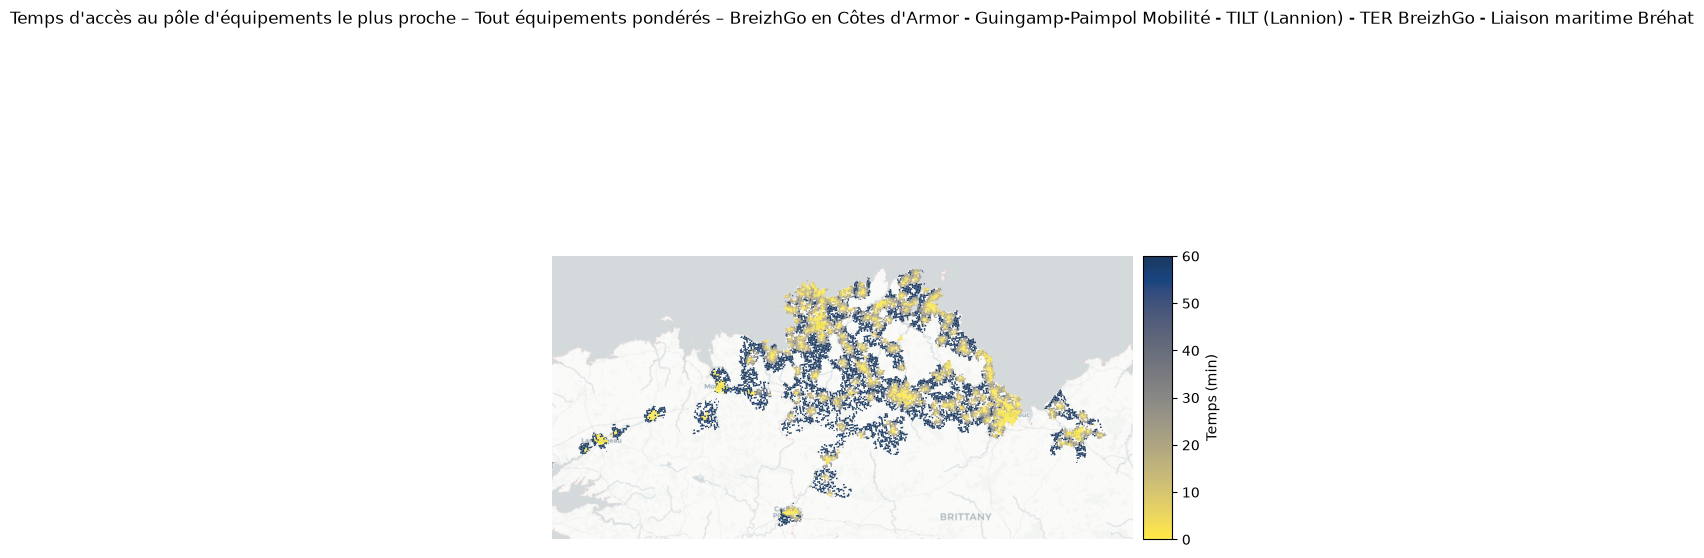

min_time calculé pour accéder à : Services pour les particuliers


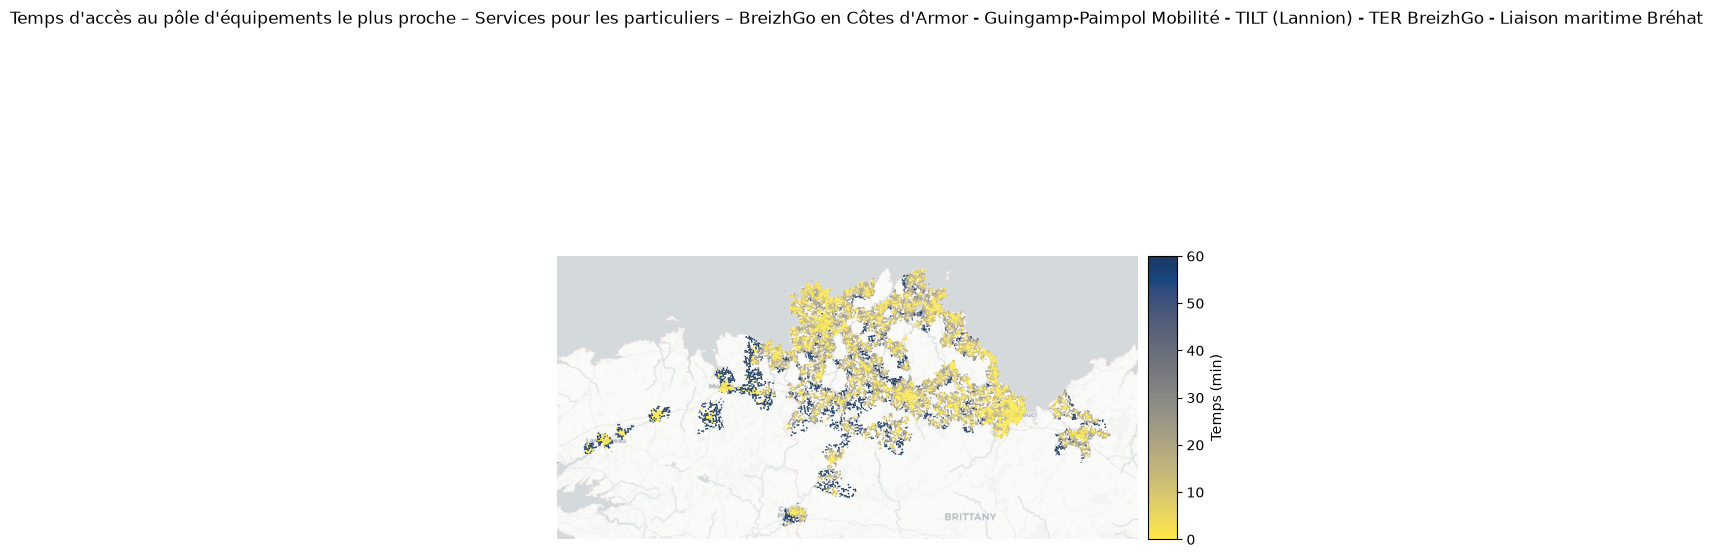

min_time calculé pour accéder à : Commerces


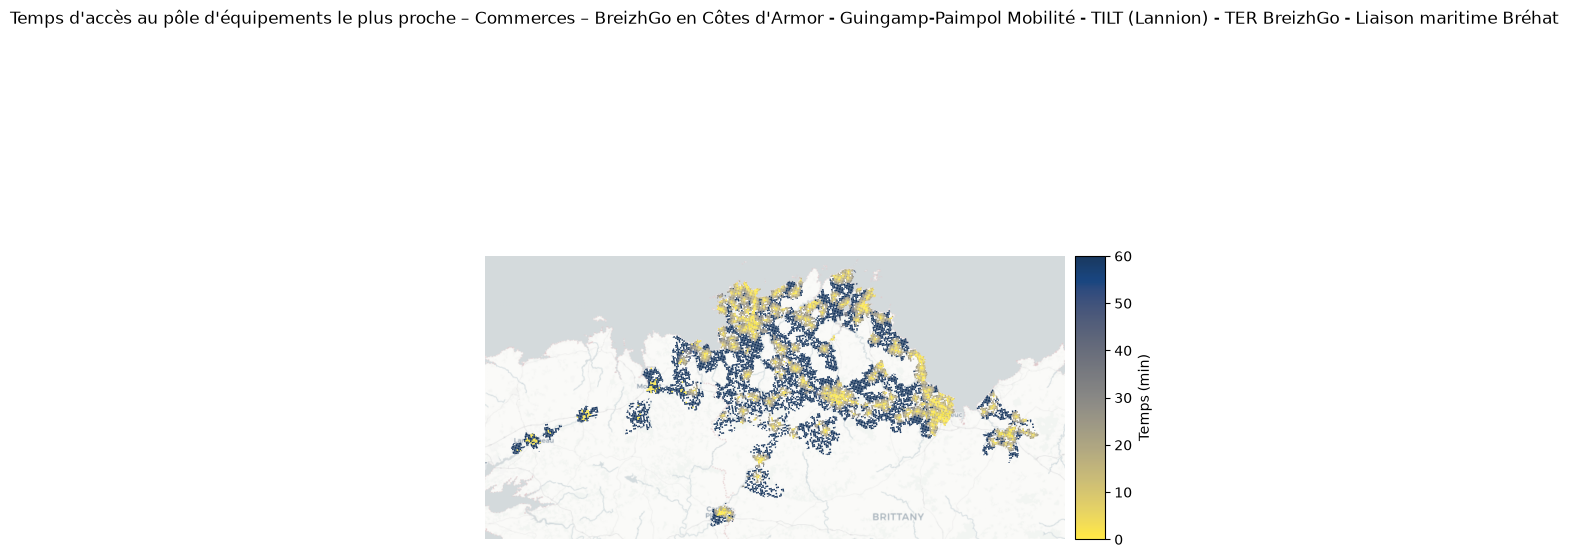

min_time calculé pour accéder à : Enseignement


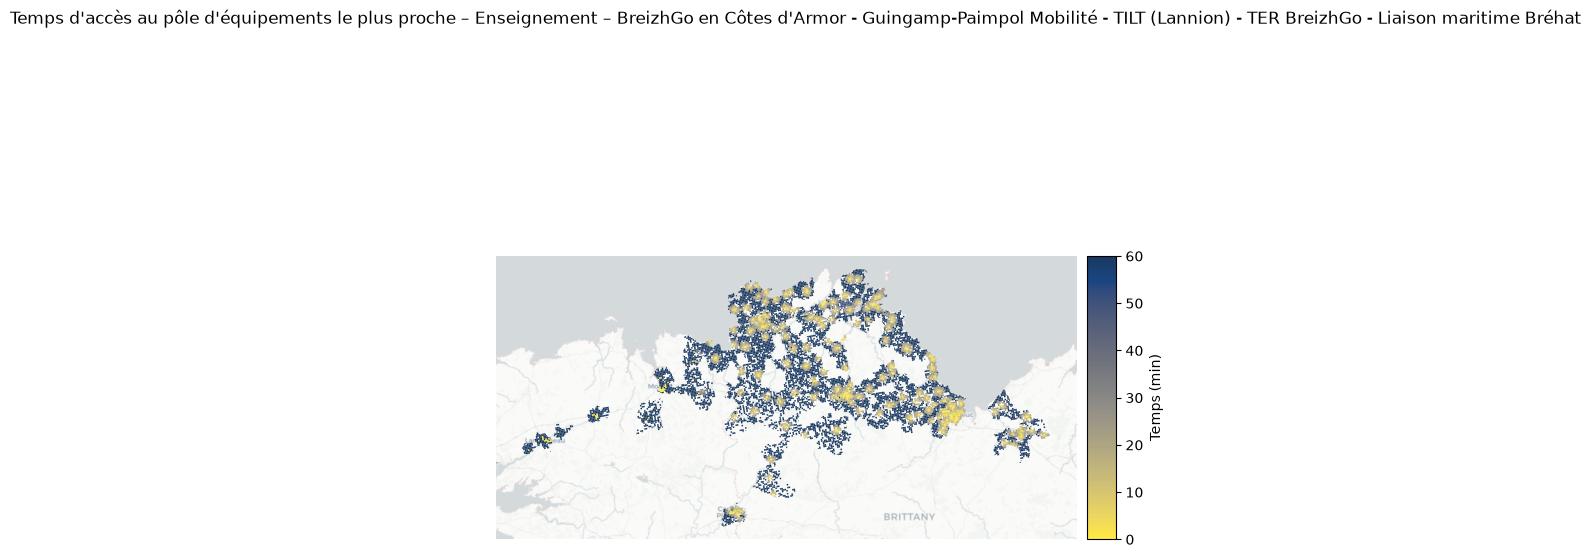

min_time calculé pour accéder à : Santé et action sociale


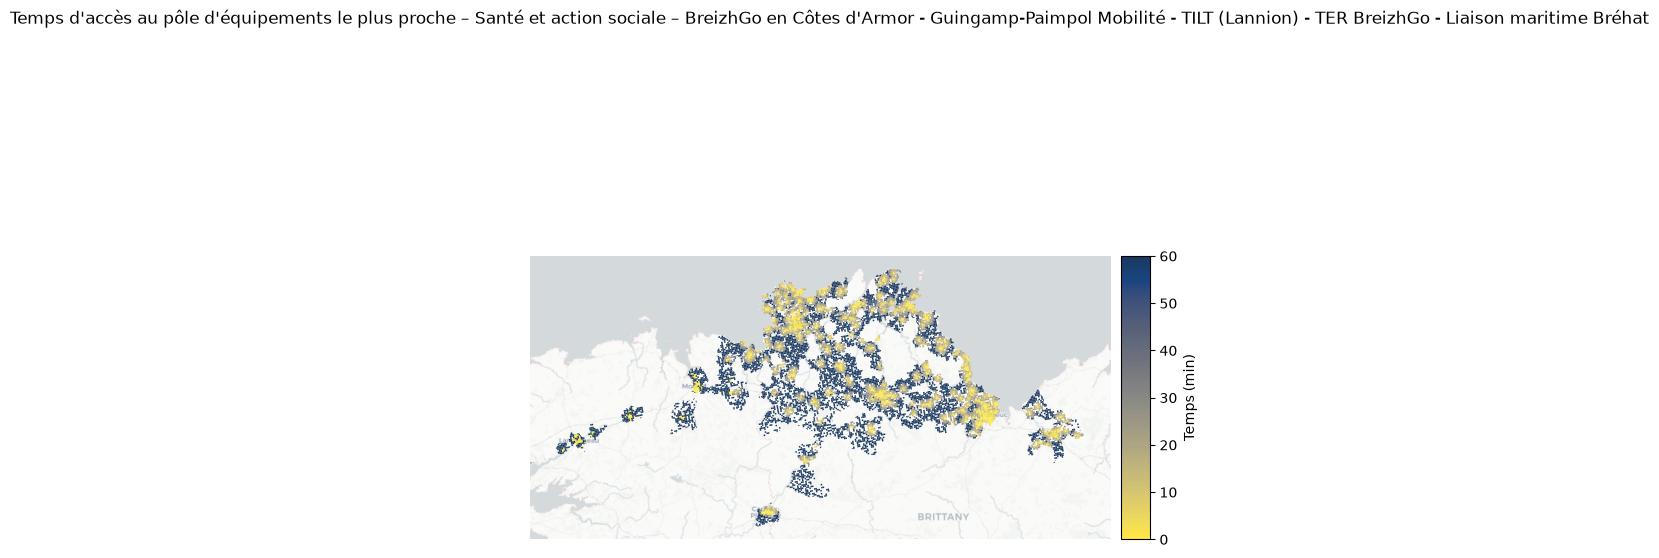

min_time calculé pour accéder à : Transports et déplacements


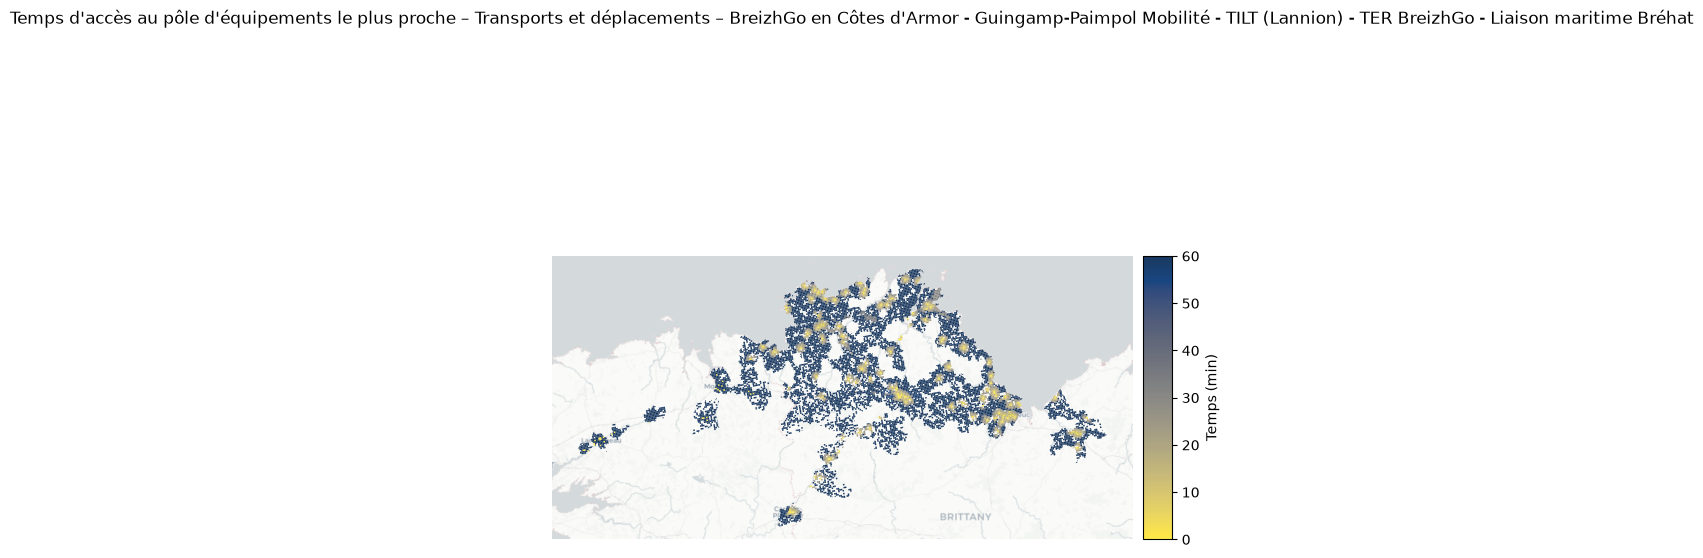

min_time calculé pour accéder à : Sports, loisirs et culture


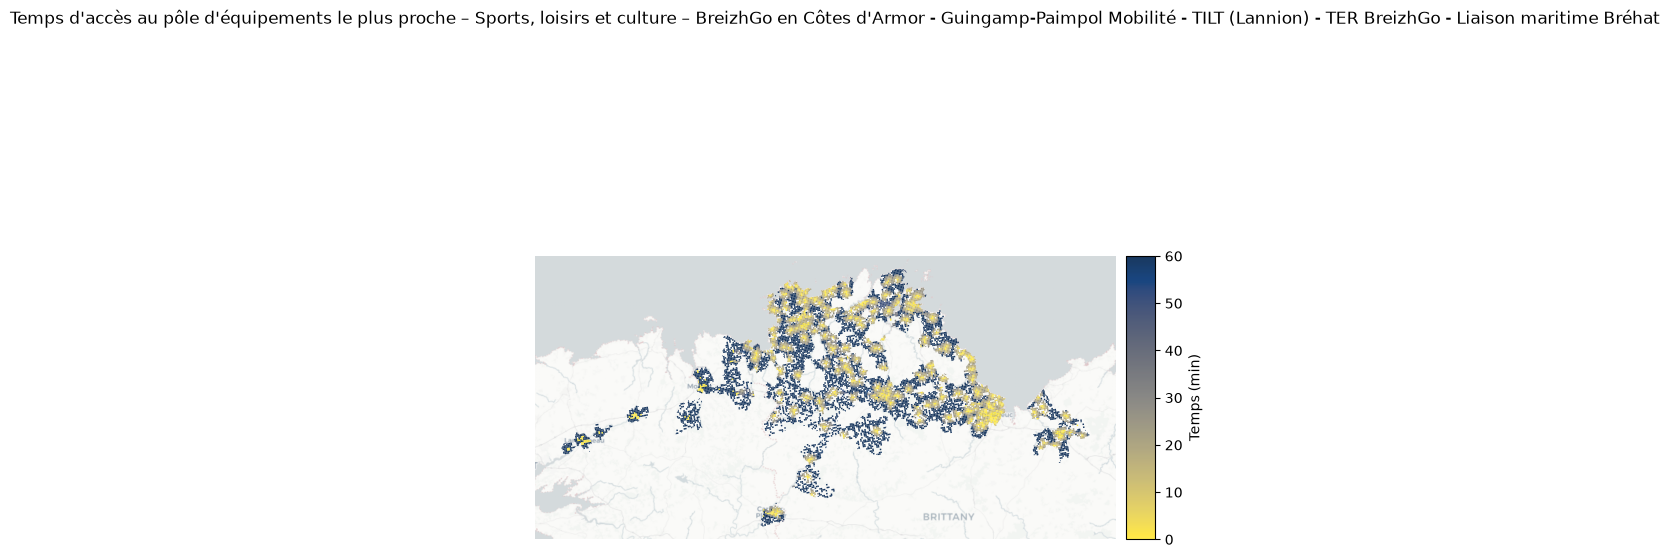

min_time calculé pour accéder à : Tourisme


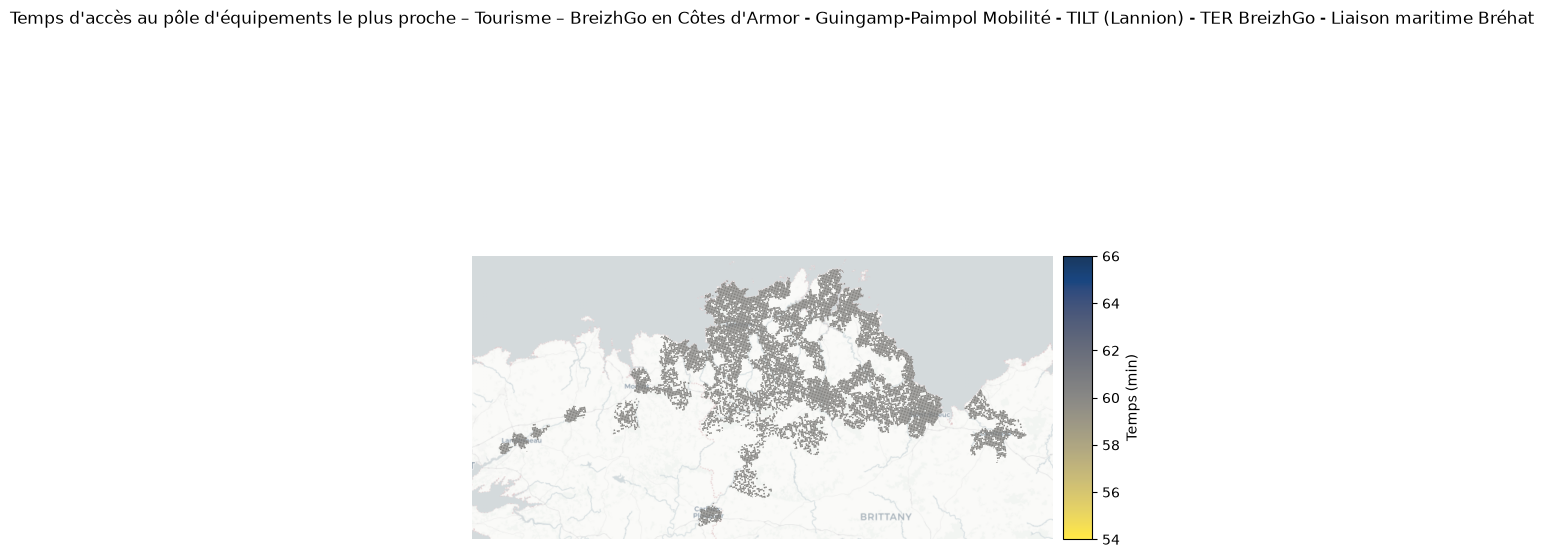

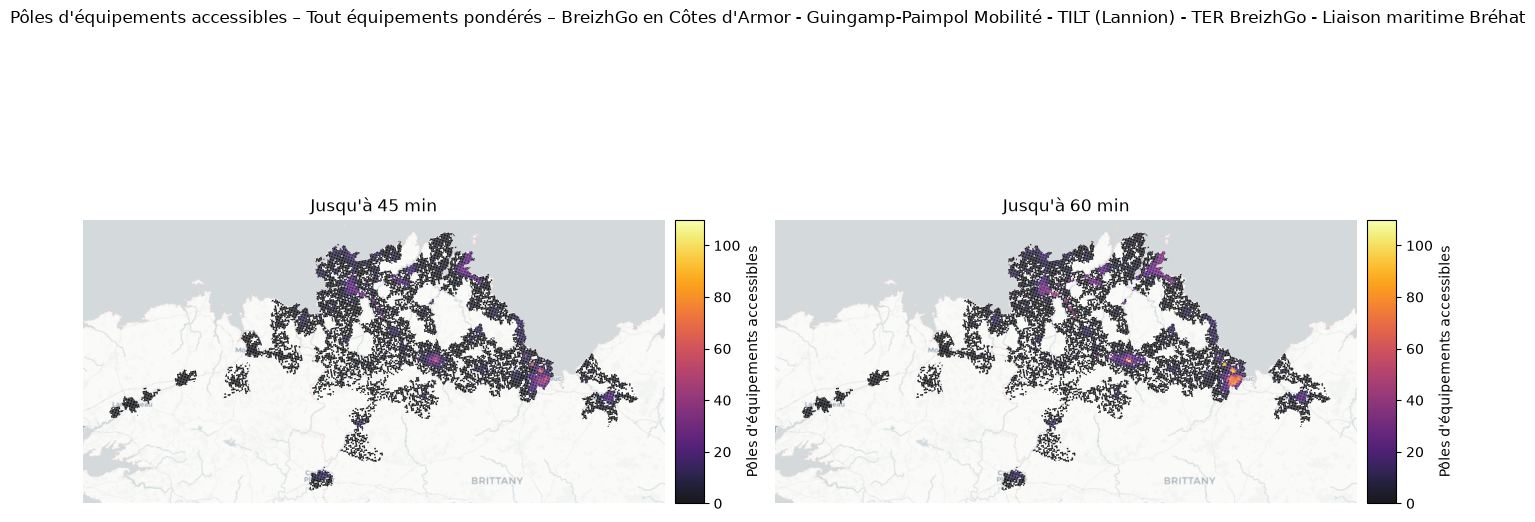

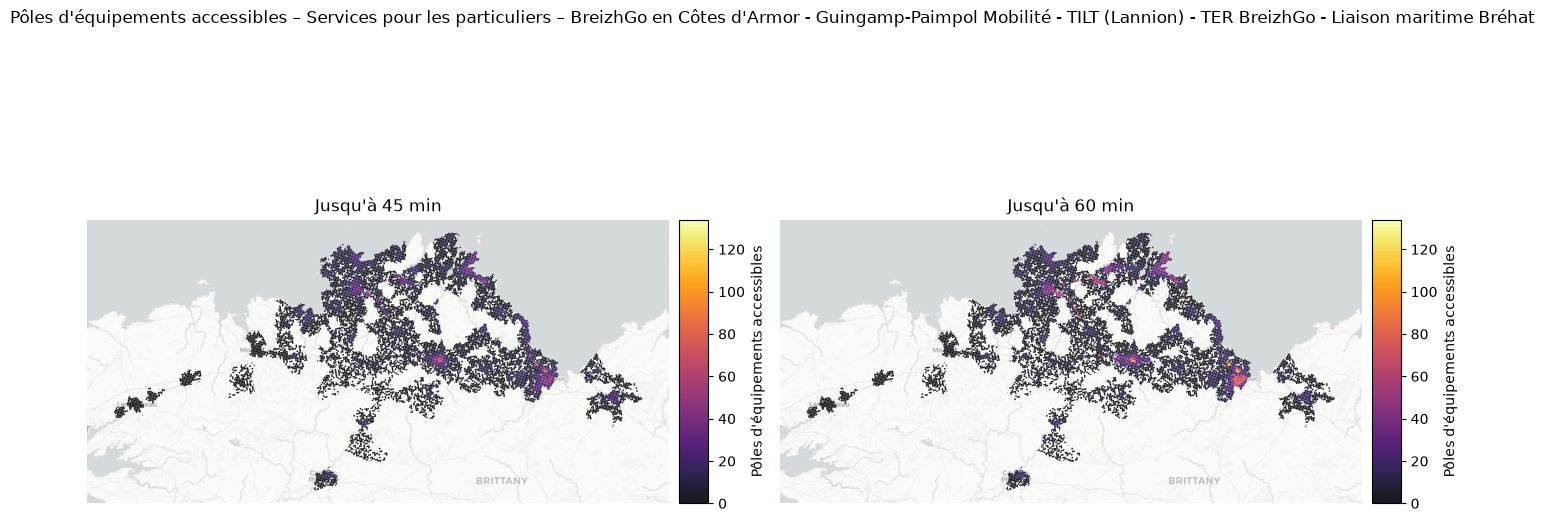

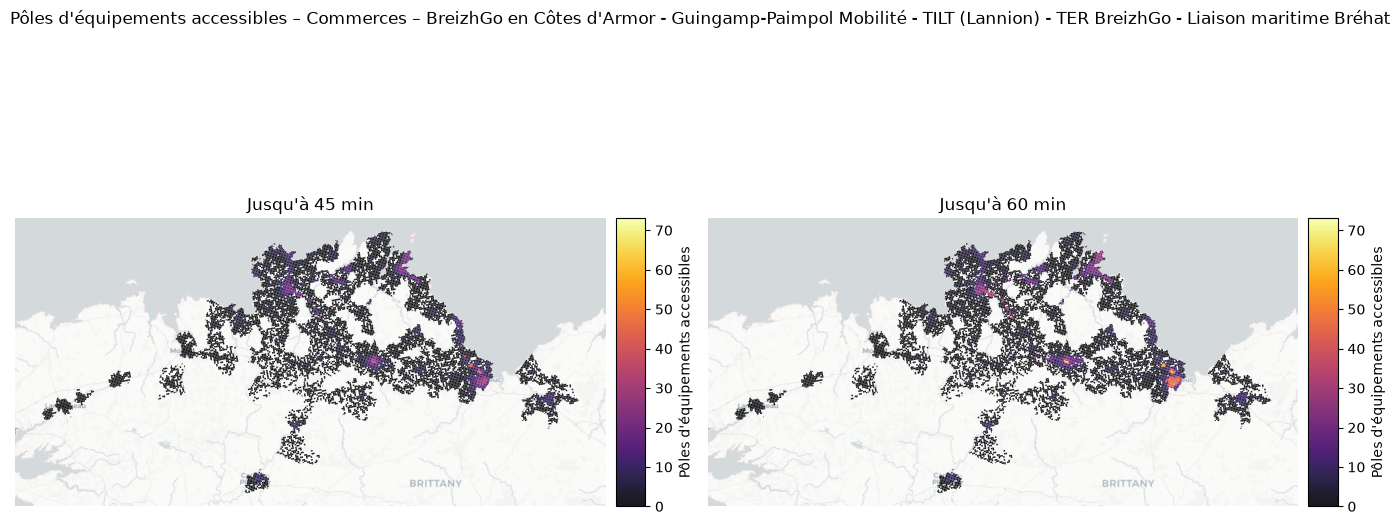

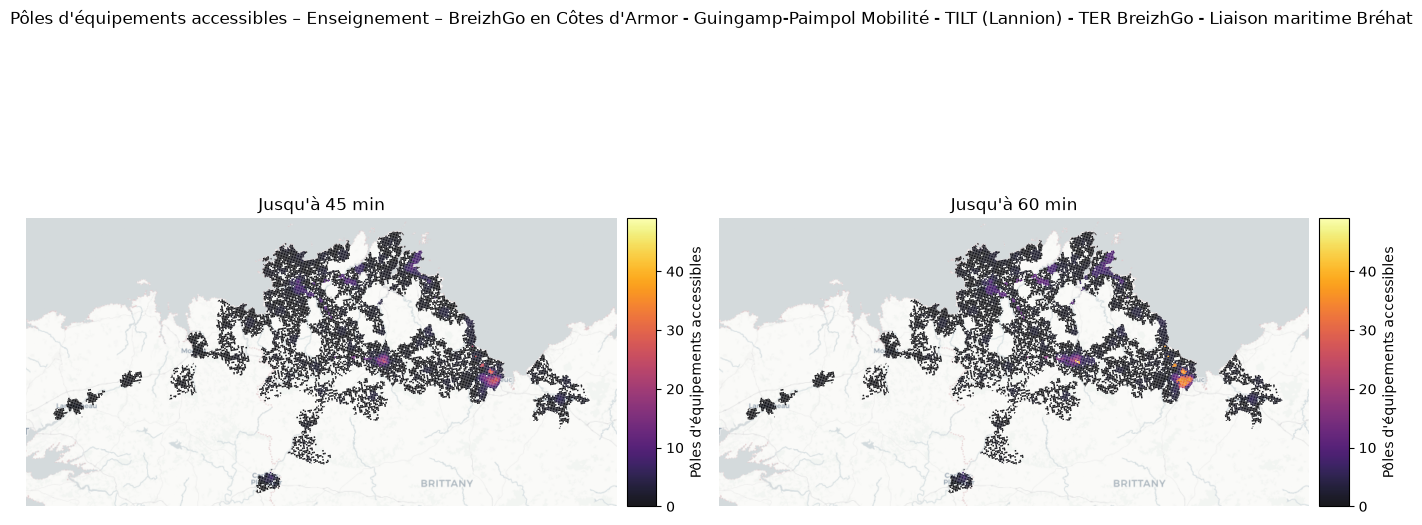

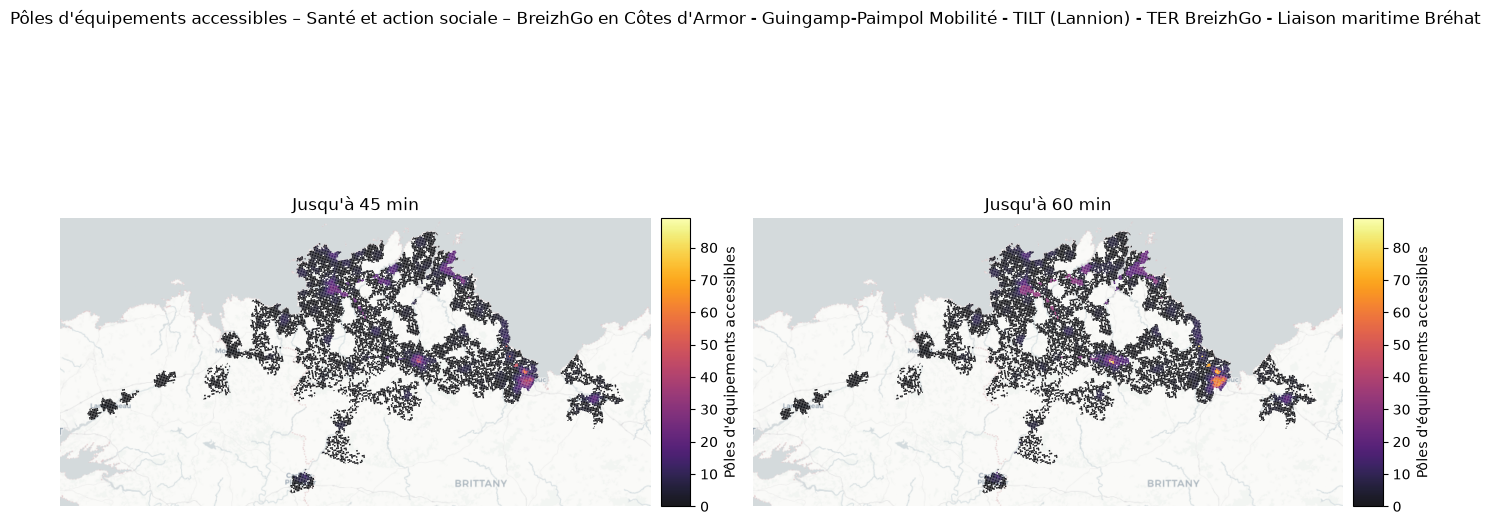

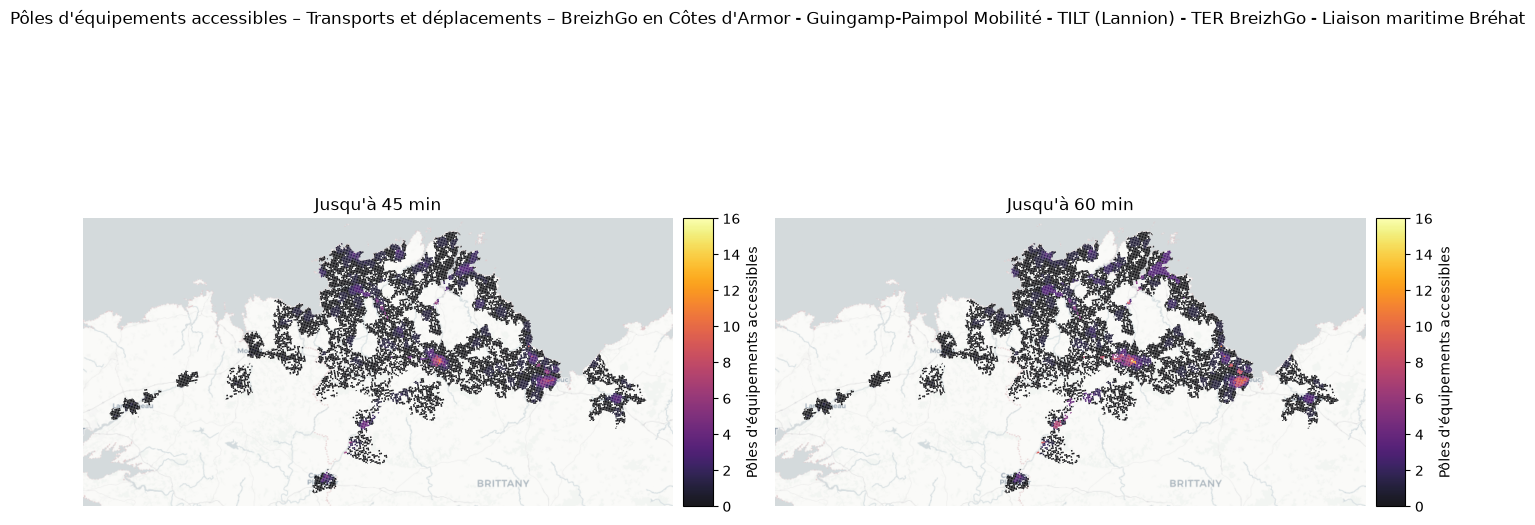

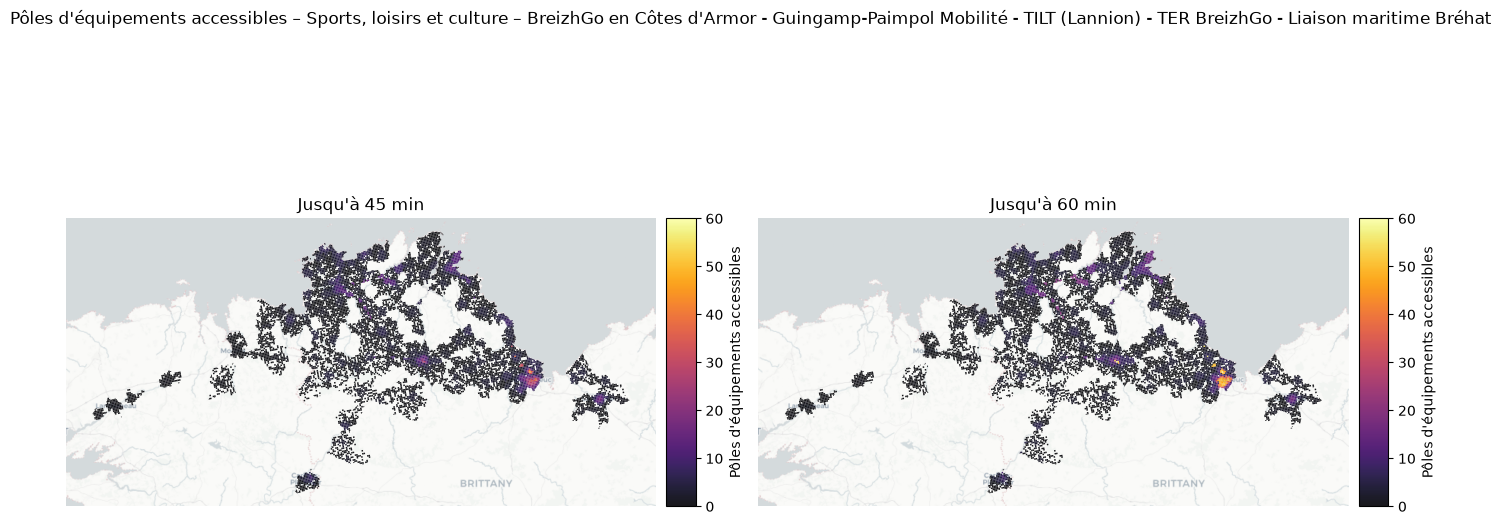

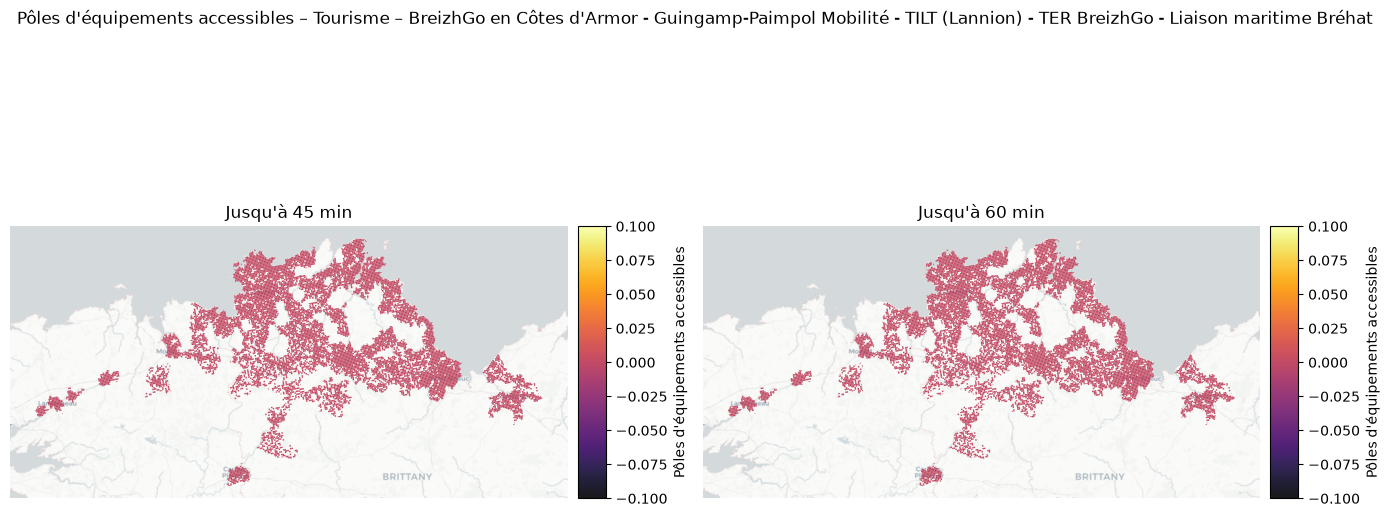

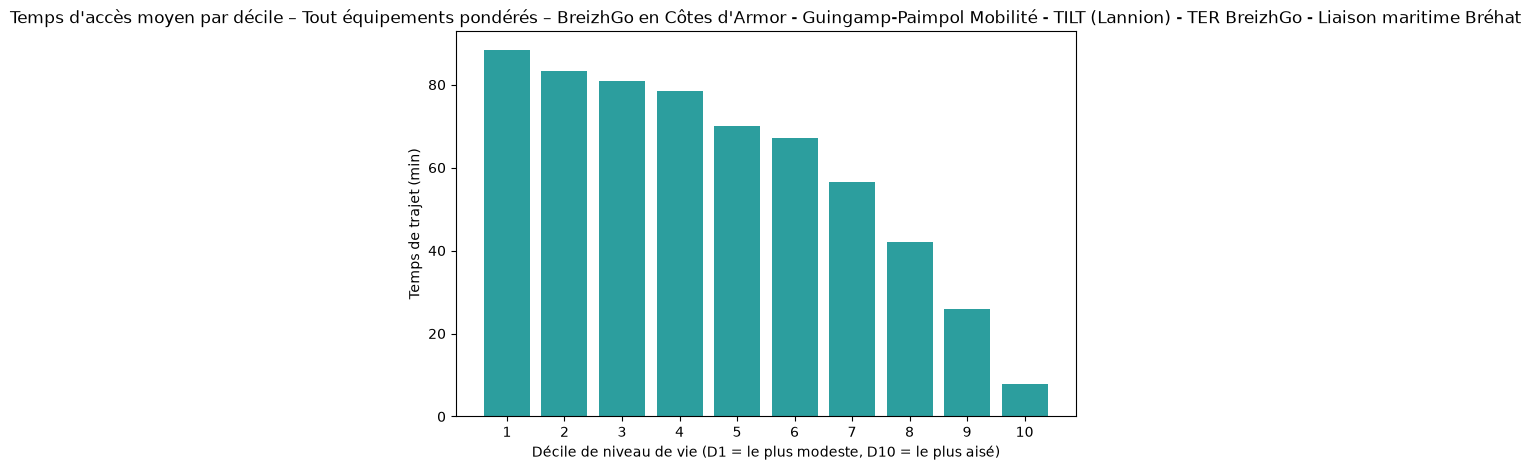

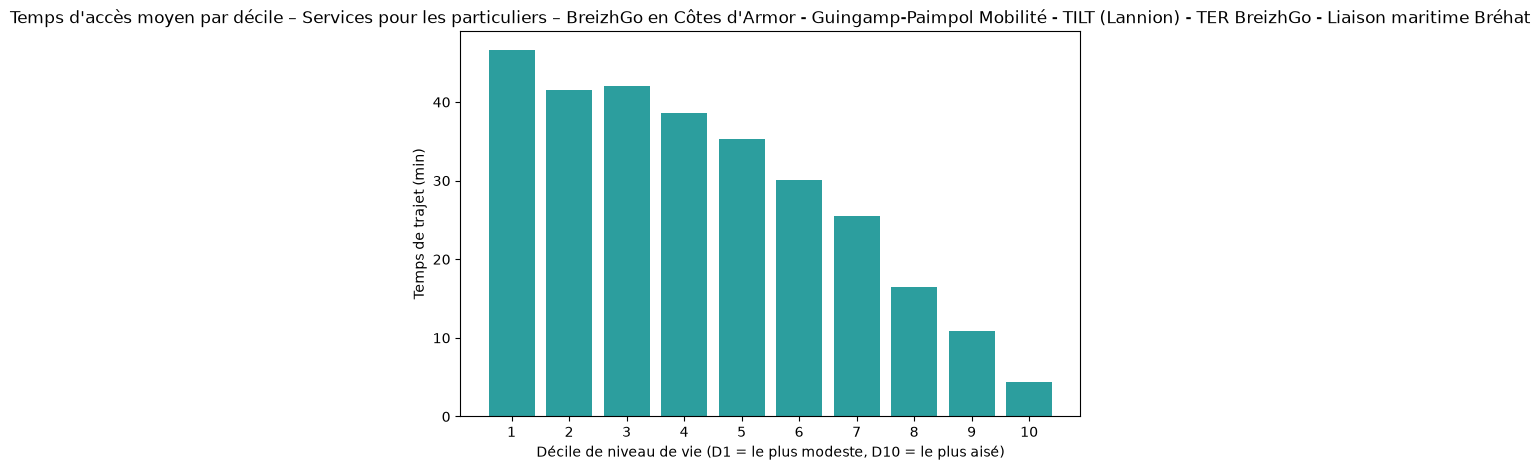

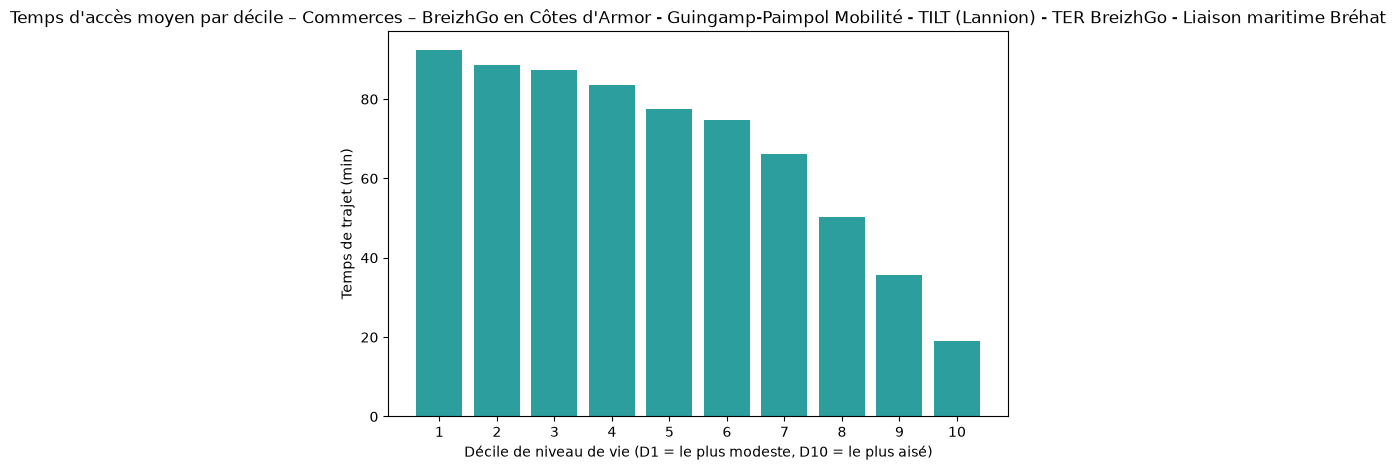

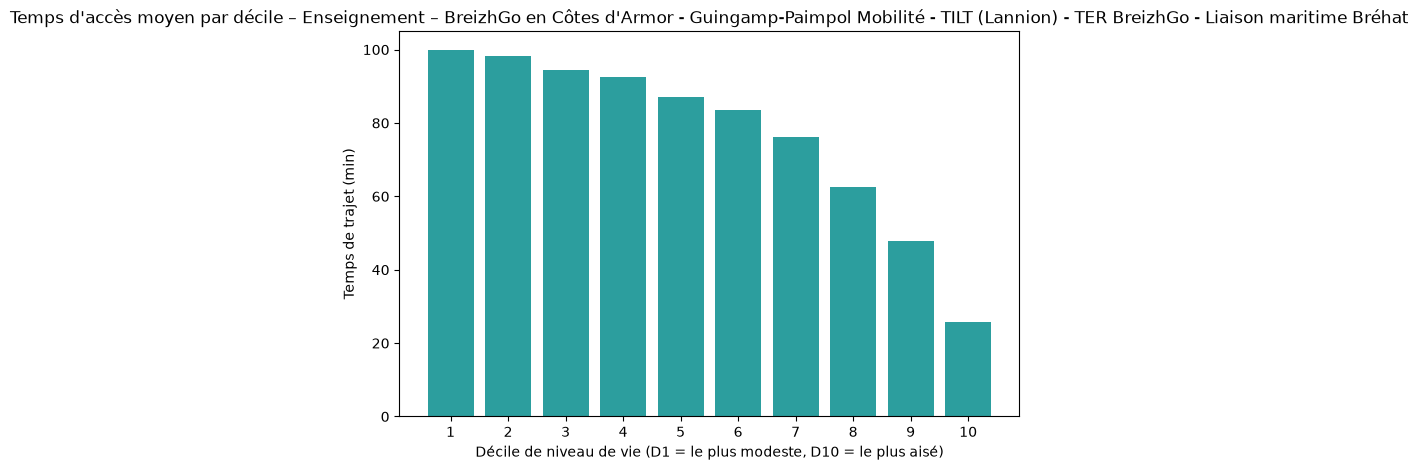

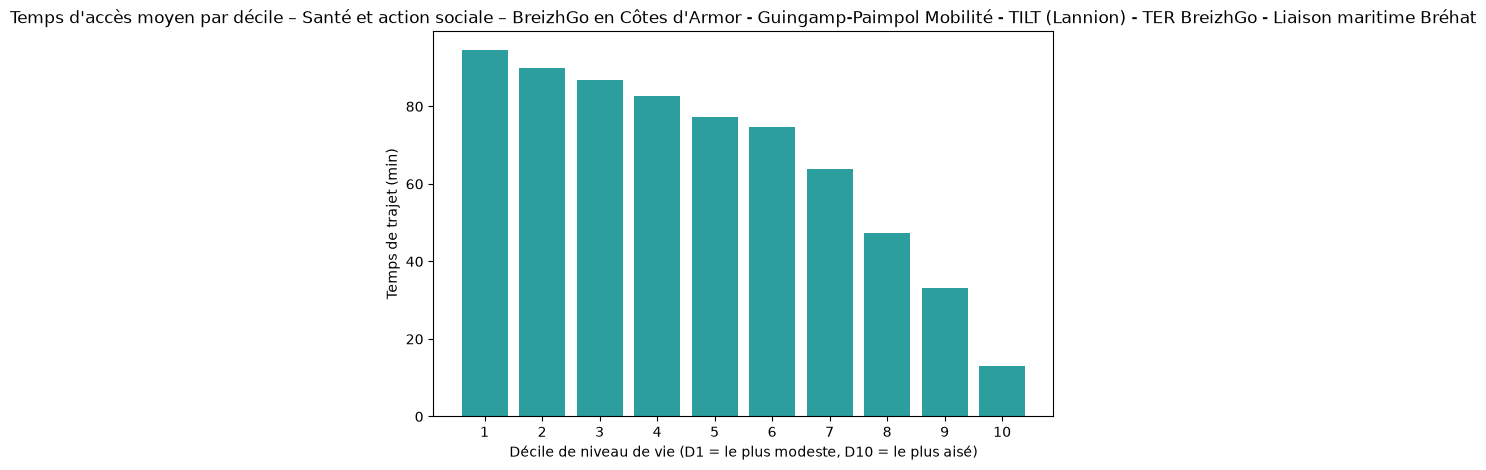

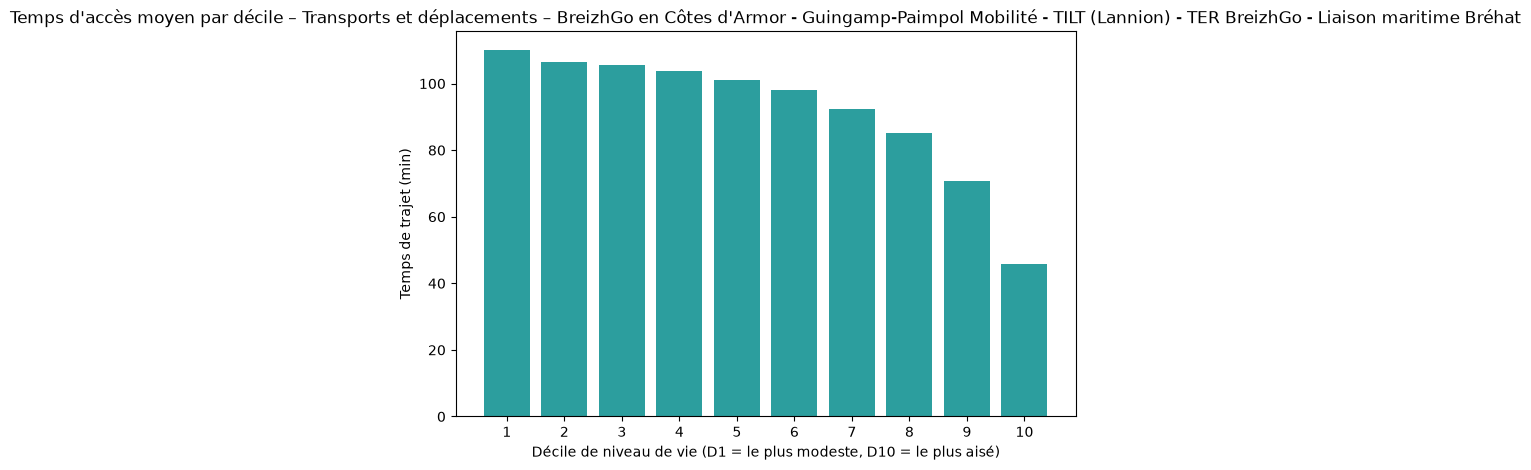

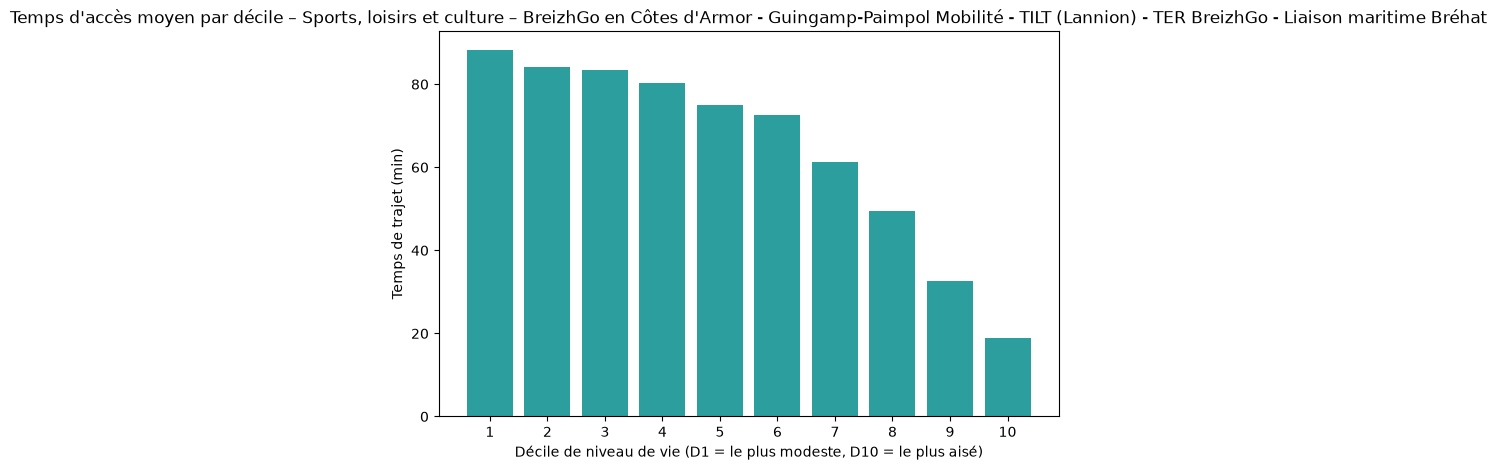

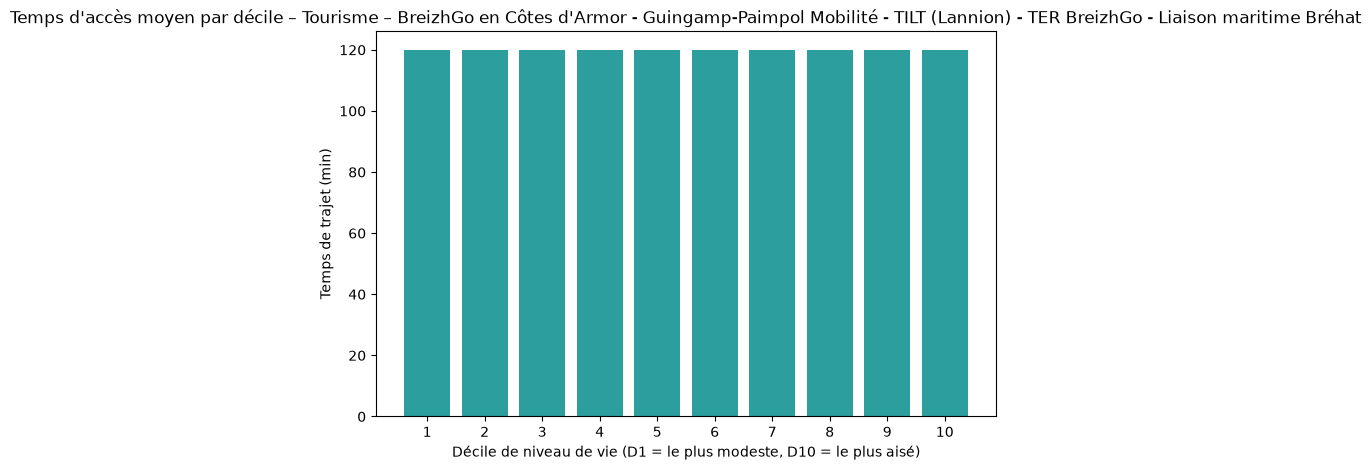

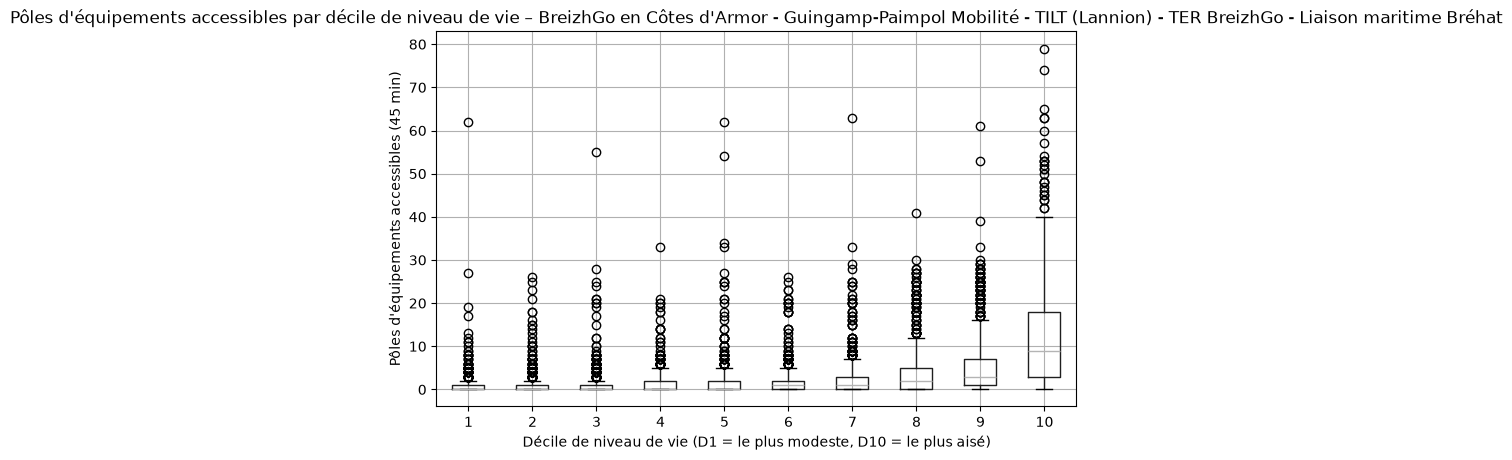

In [16]:
# analyse accessibilite / pop
#
# Adapté du chapitre 9 "Estimating accessibility levels using aopdata" du livre
# Introduction to Urban Accessibility (Pereira & Herszenhut, Ipea) :
# https://ipeagit.github.io/intro_access_book/9_aopdata_acessibilidade.en.html
#
# Équivalences avec nos données (pas de package aopdata pour la France) :
# - TMISA (temps min. vers un hôpital)      -> cost_to_closest(domaine="D")
# - CMATT30/60/90 (emplois cumulés)         -> cumulative_cutoff(domaine="O", cutoff=45/60)
#   (le BPE n'a pas de données d'emploi : "O" = tous équipements pondérés sert de proxy)
# - R003 (décile de revenu, référentiel national aopdata) -> décile de "ind_snv"
#   (indice de niveau de vie, Filosofi), calculé localement sur les carreaux
#   de l'agglo (pas de référentiel national ici)
# - P001 (population)                       -> land_use_data["population"]
#
# Différence de périmètre avec le livre : pas de comparaison voiture/marche/TC
# séparée (notre TravelTimeMatrix combine WALK+TRANSIT en un seul mode), donc
# pas de facet_wrap par mode ni de partie 4 (comparaison multi-villes voiture
# vs marche, hors périmètre d'un outil à une seule agglomération).
#
# 9.1 et 9.2 sont bouclés sur tous les domaines BPE (DOMAINES_BPE, y compris
# "O" = tout équipements pondérés) plutôt que figés sur un seul domaine, et
# exportent chacun une carte PNG (statique) et une carte HTML (interactive)
# sous output/{nom_reseau_str}/accessibilite_pop_{domaine}_{nom_reseau_str}.{png,html}.
# Les deux sont restreints aux carreaux "pôles" (pole_equipements_{domaine},
# cf. SEUILS_DOMAINE en cellule "analyse BPE 1.1") plutôt qu'à n'importe quel
# carreau ayant de l'équipement : on mesure l'accès aux pôles, pas à n'importe
# quel équipement isolé.
# 9.3 (inégalités par décile de niveau de vie) reste sur un seul couple de
# résultats (santé "D" pour le temps d'accès, "O" pour l'accessibilité cumulée),
# pour ne pas multiplier les graphiques par décile pour chaque domaine.
#
# NB : nécessite que population_grid_agglo contienne la colonne "ind_snv"
# (ajoutée à build_grid_agglo() le 22/07) : si vous travaillez sur un carroyage
# généré avant cette date, relancez la cellule "Carroyage 200x200 INSEE".

from folium.plugins import DualMap

# Un sous-dossier par réseau (nom_reseau_str) sous output/, pour ne pas mélanger
# les exports de plusieurs agglomérations dans le même dossier.
output_path_reseau = os.path.join(output_path, nom_reseau_str)
os.makedirs(output_path_reseau, exist_ok=True)

_land_use_data_global = land_use_data

# --- 9.1 Carte du temps d'accès au pôle d'équipements le plus proche, par domaine --

min_time_par_domaine = {}

for d, nom_domaine in DOMAINES_BPE.items():
    # Restreint aux carreaux "pôles" (pole_equipements_{d}) plutôt qu'à
    # n'importe quel carreau ayant au moins 1 unité d'équipement (comportement
    # par défaut de cost_to_closest quand land_use_data n'est pas fourni).
    poles_d = land_use_data[["id", f"pole_equipements_{d}"]].rename(columns={f"pole_equipements_{d}": d})

    min_time_d = cost_to_closest(
        land_use_data_domaine,
        BPE_agglo,
        _land_use_data_global,
        DOMAINES_BPE,
        ttm,
        opportunity=d,
        travel_cost="travel_time",
        land_use_data=poles_d,
    )
    min_time_par_domaine[d] = min_time_d

    # Comme TMISA dans le livre : plafonné à 60 min pour la lisibilité de la carte
    # (au-delà, seule l'idée de "trop loin" compte, pas la valeur exacte).
    carte_temps = population_grid_agglo[["id", "geometry"]].merge(min_time_d, on="id")
    carte_temps["travel_time_plafonne"] = carte_temps["travel_time"].clip(upper=60)

    fig, ax = plt.subplots(figsize=(8, 8))
    carte_temps.to_crs(epsg=3857).plot(
        column="travel_time_plafonne",
        cmap="cividis_r",
        alpha=0.9,
        legend=False,
        edgecolor="none",
        ax=ax,
    )

    # Colorbar calée sur la hauteur réelle de la carte (cf. cellule 3.3.1) :
    # legend=True donnerait une colorbar de la hauteur de la figure entière,
    # plus grande que la carte une fois l'aspect ratio géographique appliqué.
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(ax.collections[0], cax=cax, label="Temps (min)")

    ctx.add_basemap(ax, source=source_contextily_cartodb("light_all") or ctx.providers.OpenStreetMap.Mapnik, crs="EPSG:3857")
    ax.set_axis_off()
    fig.suptitle(f"Temps d'accès au pôle d'équipements le plus proche – {nom_domaine} – {nom_reseau_str}")

    chemin_base_9_1 = os.path.join(output_path_reseau, f"accessibilite_pop_temps_{d}_{nom_reseau_str}")
    plt.savefig(f"{chemin_base_9_1}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Export HTML interactif équivalent (contours des carreaux transparents,
    # cf. carte_ponderation_domaine / cellule 3.3.1).
    carte_interactive_9_1 = carte_temps.explore(
        column="travel_time_plafonne",
        cmap="cividis_r",
        **fond_carte_kwargs(FONDS_CARTE[FOND_CARTE]),
        legend=False,  # légende maison ci-dessous (cf. echelle_continue_html) :
        # .explore(legend=True) positionne en haut à droite (branca), ce qui
        # chevauche le titre flottant (titre_carte_html, en haut).
        style_kwds={"weight": 0, "opacity": 0},
    )
    carte_interactive_9_1.get_root().html.add_child(
        folium.Element(titre_carte_html(
            f"Temps d'accès au pôle d'équipements le plus proche – {nom_domaine} – {nom_reseau_str}"
        ))
    )
    carte_interactive_9_1.get_root().html.add_child(
        folium.Element(echelle_continue_html(
            carte_temps["travel_time_plafonne"].min(),
            carte_temps["travel_time_plafonne"].max(),
            "cividis_r",
            "Temps (min)",
            cote="centre",
        ))
    )

    # Réajuste le zoom si la carte est rendue dans un conteneur masqué au
    # chargement (pas le cas ici en usage notebook/fichier autonome, mais
    # cf. src/cartographie.py : même fonction que celle utilisée par l'app
    # Streamlit, pour rester cohérent entre les deux exports).
    minx_9_1, miny_9_1, maxx_9_1, maxy_9_1 = carte_temps.to_crs(epsg=4326).total_bounds
    carte_interactive_9_1.get_root().html.add_child(
        folium.Element(script_reajuster_si_masque(
            carte_interactive_9_1, [[miny_9_1, minx_9_1], [maxy_9_1, maxx_9_1]]
        ))
    )

    carte_interactive_9_1.save(f"{chemin_base_9_1}.html")

# --- 9.2 Carte du nombre de pôles d'équipements accessibles, par domaine (45 vs 60 min) --

cum_45_par_domaine = {}
cum_60_par_domaine = {}

for d, nom_domaine in DOMAINES_BPE.items():
    # Restreint aux carreaux "pôles" (pole_equipements_{d}) : cum_45_d/cum_60_d
    # comptent le nombre de pôles accessibles, pas une somme pondérée continue
    # sur tous les carreaux ayant de l'équipement.
    poles_d = land_use_data[["id", f"pole_equipements_{d}"]].rename(columns={f"pole_equipements_{d}": d})

    cum_45_d = cumulative_cutoff(ttm, land_use_data=poles_d, opportunity=d, travel_cost="travel_time", cutoff=45)
    cum_60_d = cumulative_cutoff(ttm, land_use_data=poles_d, opportunity=d, travel_cost="travel_time", cutoff=60)
    cum_45_par_domaine[d] = cum_45_d
    cum_60_par_domaine[d] = cum_60_d

    limite_commune = max(cum_45_d[d].max(), cum_60_d[d].max())

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    for ax, cum, titre in zip(axes, [cum_45_d, cum_60_d], ["Jusqu'à 45 min", "Jusqu'à 60 min"]):
        carte = population_grid_agglo[["id", "geometry"]].merge(cum, on="id").to_crs(epsg=3857)
        carte.plot(
            column=d, cmap="inferno", vmin=0, vmax=limite_commune, alpha=0.9,
            legend=False, edgecolor="none", ax=ax,
        )

        # Colorbar calée sur la hauteur réelle de chaque carte (cf. cellules
        # 3.3.1 et 9.1) : legend=True donnerait une colorbar de la hauteur de
        # la figure entière, plus grande que la carte une fois l'aspect ratio
        # géographique appliqué.
        from mpl_toolkits.axes_grid1 import make_axes_locatable

        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        fig.colorbar(ax.collections[0], cax=cax, label="Pôles d'équipements accessibles")

        ctx.add_basemap(ax, source=source_contextily_cartodb("light_all") or ctx.providers.OpenStreetMap.Mapnik, crs="EPSG:3857")
        ax.set_axis_off()
        ax.set_title(titre)
    fig.suptitle(f"Pôles d'équipements accessibles – {nom_domaine} – {nom_reseau_str}")
    plt.tight_layout()

    chemin_base_9_2 = os.path.join(output_path_reseau, f"accessibilite_pop_cumule_{d}_{nom_reseau_str}")
    plt.savefig(f"{chemin_base_9_2}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Export HTML interactif : DualMap (folium.plugins) = deux cartes synchronisées
    # côte à côte (45 min à gauche, 60 min à droite) dans un seul fichier HTML,
    # même principe que le PNG ci-dessus mais interactif.
    carte_45 = population_grid_agglo[["id", "geometry"]].merge(cum_45_d, on="id")
    carte_60 = population_grid_agglo[["id", "geometry"]].merge(cum_60_d, on="id")

    dual_map = DualMap(**fond_carte_kwargs(FONDS_CARTE[FOND_CARTE]), layout="horizontal")
    # legend=False sur les deux : branca cible tous les colorbars de la page
    # via un sélecteur CSS non isolé par carte (d3.select(".legend.leaflet-control"),
    # premier match seulement) — le second colorbar s'empile dans le premier
    # au lieu de s'afficher sur son propre panneau. Légendes maison à la
    # place (cf. echelle_continue_html ci-dessous), une par côté.
    carte_45.explore(
        column=d, cmap="inferno", vmin=0, vmax=limite_commune,
        legend=False,
        style_kwds={"weight": 0, "opacity": 0}, m=dual_map.m1,
    )
    carte_60.explore(
        column=d, cmap="inferno", vmin=0, vmax=limite_commune,
        legend=False,
        style_kwds={"weight": 0, "opacity": 0}, m=dual_map.m2,
    )

    # .explore(m=...) ajoute la couche à une carte existante sans recentrer
    # dessus (contrairement à .explore() sans m=, qui fait un fit_bounds
    # automatique) : DualMap() démarre donc sur sa vue par défaut ([0, 0],
    # zoom 1) sans ce fit_bounds explicite sur les deux volets.
    minx, miny, maxx, maxy = carte_45.to_crs(epsg=4326).total_bounds
    dual_map.m1.fit_bounds([[miny, minx], [maxy, maxx]])
    dual_map.m2.fit_bounds([[miny, minx], [maxy, maxx]])

    dual_map.get_root().html.add_child(
        folium.Element(titre_carte_html(
            f"Pôles d'équipements accessibles – {nom_domaine} – {nom_reseau_str} (45 min / 60 min)"
        ))
    )
    dual_map.get_root().html.add_child(
        folium.Element(echelle_continue_html(0, limite_commune, "inferno", f"{nom_domaine} (pôles) – 45 min", cote="gauche"))
    )
    dual_map.get_root().html.add_child(
        folium.Element(echelle_continue_html(0, limite_commune, "inferno", f"{nom_domaine} (pôles) – 60 min", cote="droite"))
    )
    dual_map.get_root().html.add_child(
        folium.Element(script_reajuster_si_masque(dual_map.m1, [[miny, minx], [maxy, maxx]]))
    )
    dual_map.get_root().html.add_child(
        folium.Element(script_reajuster_si_masque(dual_map.m2, [[miny, minx], [maxy, maxx]]))
    )
    dual_map.save(f"{chemin_base_9_2}.html")

# Réutilisé en 9.3 (inégalités) : nombre de pôles d'équipements accessibles (tout domaine, 45 min)
cum_45 = cum_45_par_domaine["O"]

# --- 9.3 Inégalités d'accessibilité selon le niveau de vie ------------------

# Décile de niveau de vie calculé localement sur les carreaux de l'agglo
# (le livre utilise un décile national ; pas de référentiel équivalent ici).
# On exclut les carreaux sans donnée publiée (ind_snv <= 0, secret statistique) :
# les inclure fausserait le décile le plus pauvre avec des carreaux "sans donnée".
niveau_vie = population_grid_agglo.loc[population_grid_agglo["ind_snv"] > 0, ["id", "ind_snv"]].copy()
niveau_vie["decile_niveau_vie"] = (
    pd.qcut(niveau_vie["ind_snv"], 10, labels=False, duplicates="drop") + 1
)

# Temps d'accès moyen par décile, pondéré par la population, décliné pour
# chaque domaine BPE (min_time_par_domaine calculé en 9.1) plutôt que figé
# sur la santé.
def moyenne_ponderee(groupe):
    poids = groupe["population"]
    return (groupe["travel_time"] * poids).sum() / poids.sum() if poids.sum() > 0 else float("nan")


for d, nom_domaine in DOMAINES_BPE.items():
    ineq_temps = (
        min_time_par_domaine[d]
        .merge(niveau_vie[["id", "decile_niveau_vie"]], on="id")
        .merge(land_use_data[["id", "population"]], on="id")
    )
    # Équivalent de ifelse(is.infinite(TMISA), 120, TMISA) dans le livre : les
    # carreaux sans équipement accessible pour ce domaine sont plafonnés à
    # 120 min plutôt qu'exclus, pour ne pas biaiser la moyenne vers le bas.
    ineq_temps["travel_time"] = ineq_temps["travel_time"].replace(float("inf"), 120)

    moyennes_par_decile = (
        ineq_temps.groupby("decile_niveau_vie")
        .apply(moyenne_ponderee, include_groups=False)
        .dropna()
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(moyennes_par_decile.index.astype(int).astype(str), moyennes_par_decile.values, color="#2c9e9e")
    ax.set_xlabel("Décile de niveau de vie (D1 = le plus modeste, D10 = le plus aisé)")
    ax.set_ylabel("Temps de trajet (min)")
    ax.set_title(f"Temps d'accès moyen par décile – {nom_domaine} – {nom_reseau_str}")
    plt.show()

# Pôles d'équipements accessibles à 45 min, distribution par décile (boxplot)
ineq_cum = cum_45.merge(niveau_vie[["id", "decile_niveau_vie"]], on="id")

fig, ax = plt.subplots(figsize=(8, 5))
ineq_cum.boxplot(column="O", by="decile_niveau_vie", ax=ax)
ax.set_xlabel("Décile de niveau de vie (D1 = le plus modeste, D10 = le plus aisé)")
ax.set_ylabel("Pôles d'équipements accessibles (45 min)")
ax.set_title(f"Pôles d'équipements accessibles par décile de niveau de vie – {nom_reseau_str}")
plt.suptitle("")
plt.show()

,15 min,30 min,45 min,60 min
Domaine,,,,
Tout équipements pondérés,0.3,0.9,1.1,1.5
Services pour les particuliers,0.2,0.6,0.7,0.9
Commerces,0.3,0.9,1.1,1.4
Enseignement,0.4,1.1,1.4,1.8
Santé et action sociale,0.3,1.0,1.2,1.5
Transports et déplacements,0.2,0.8,0.9,1.2
"Sports, loisirs et culture",0.3,0.9,1.0,1.4
Tourisme,0.0,0.0,0.0,0.0


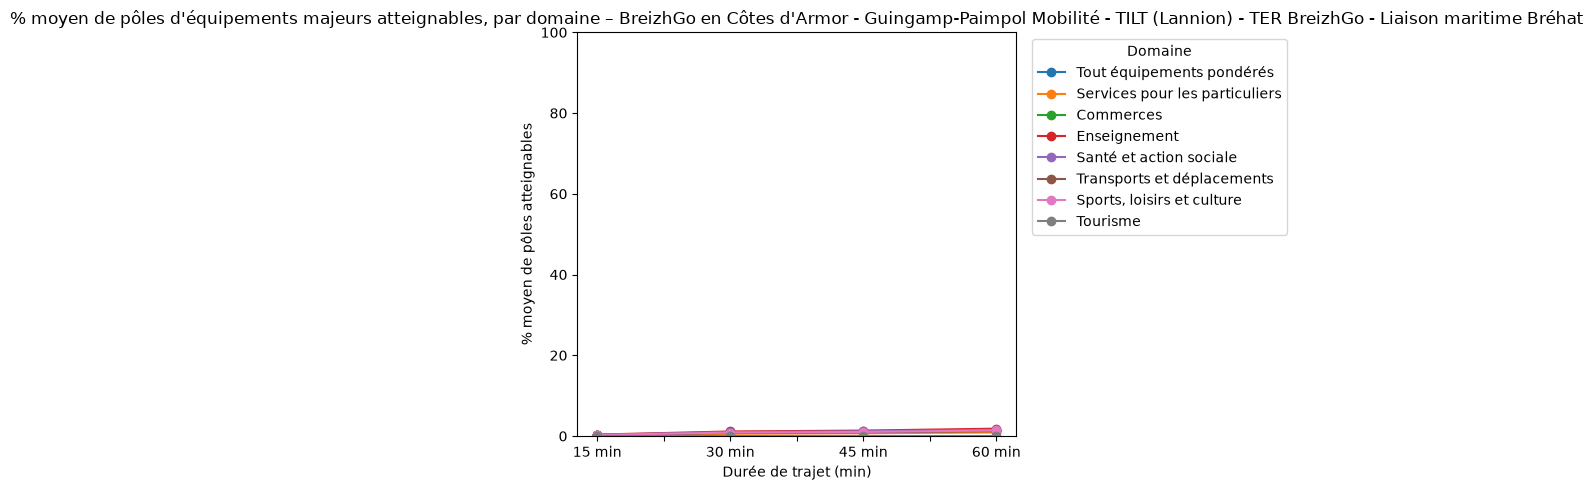

,15 min,30 min,45 min,60 min
Décile,,,,
1,0.0,0.1,0.1,0.1
2,0.0,0.1,0.1,0.1
3,0.0,0.1,0.1,0.1
4,0.0,0.1,0.1,0.1
5,0.0,0.1,0.2,0.2
6,0.0,0.1,0.2,0.2
7,0.0,0.2,0.2,0.3
8,0.1,0.3,0.4,0.5
9,0.1,0.4,0.5,0.6


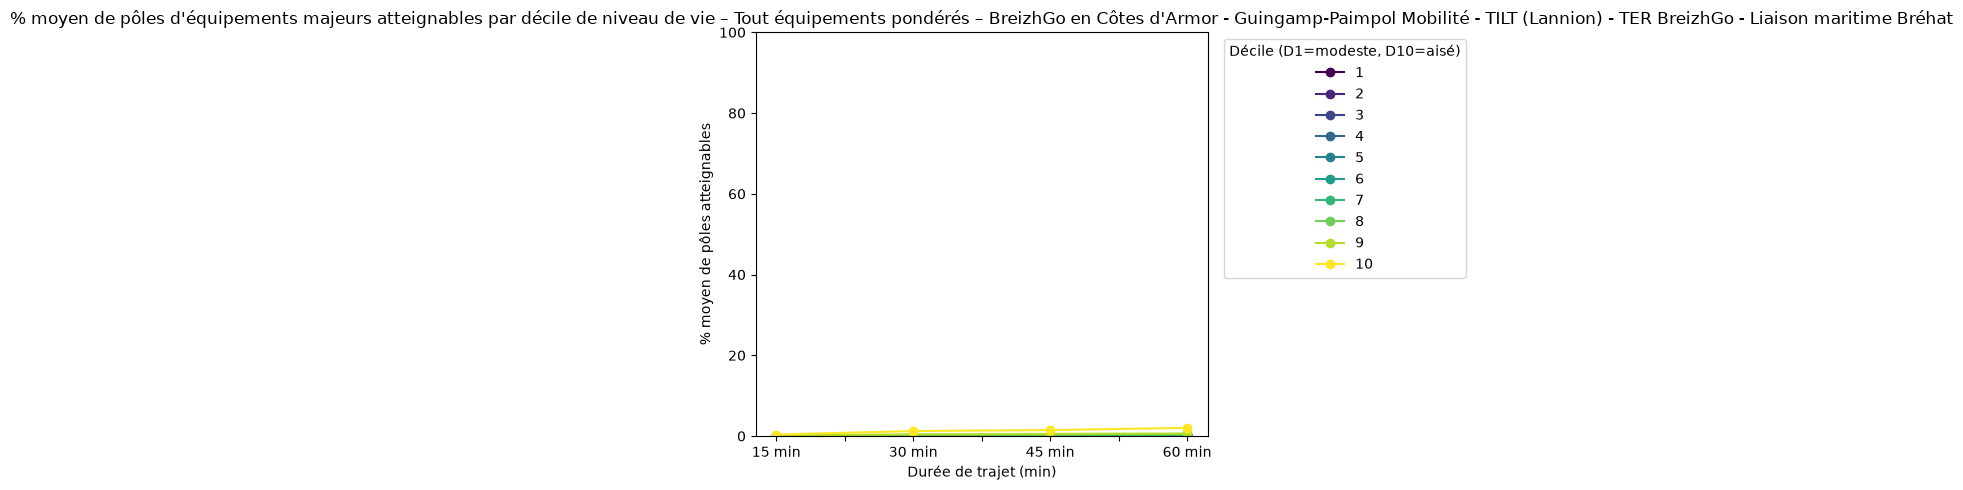

,15 min,30 min,45 min,60 min
Décile,,,,
1,0.0,0.1,0.1,0.1
2,0.0,0.1,0.1,0.1
3,0.0,0.1,0.1,0.2
4,0.0,0.1,0.2,0.2
5,0.0,0.1,0.2,0.2
6,0.0,0.2,0.2,0.2
7,0.0,0.2,0.3,0.3
8,0.1,0.3,0.3,0.4
9,0.1,0.4,0.5,0.5


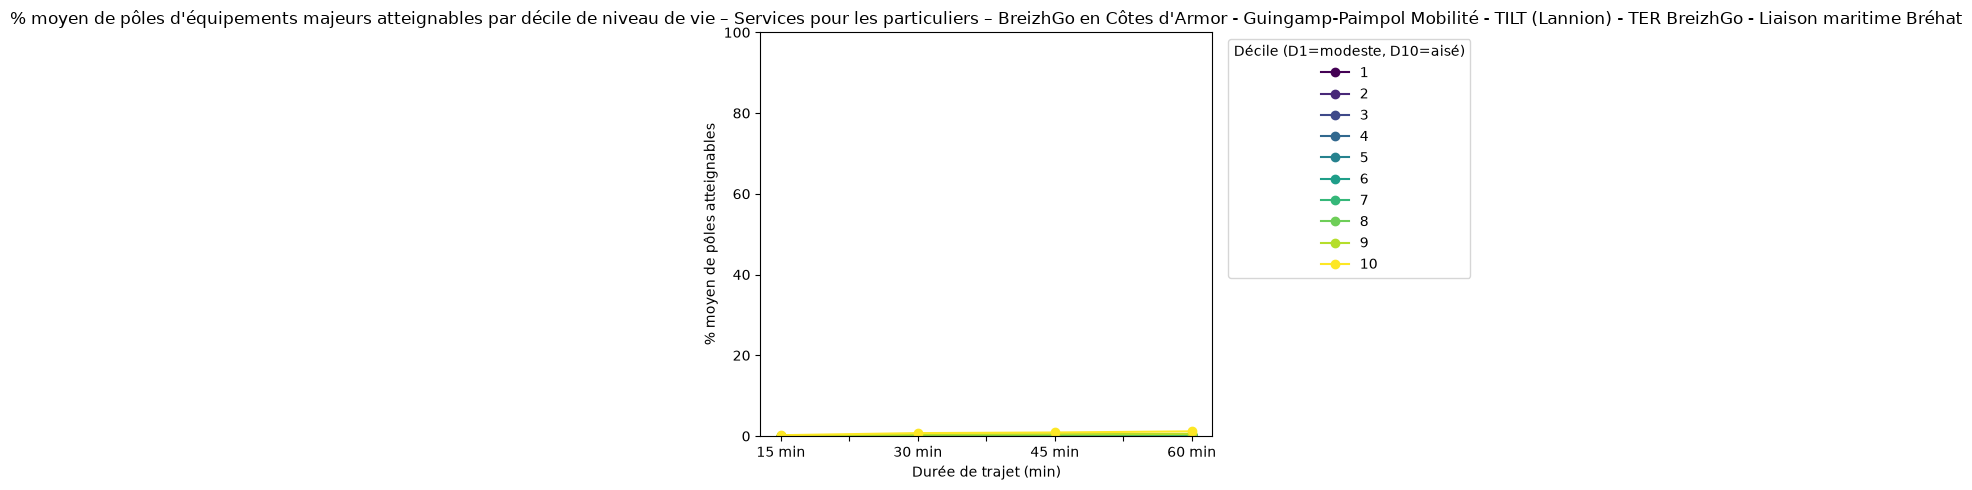

,15 min,30 min,45 min,60 min
Décile,,,,
1,0.0,0.1,0.1,0.1
2,0.0,0.1,0.1,0.1
3,0.0,0.1,0.1,0.1
4,0.0,0.1,0.1,0.1
5,0.0,0.1,0.2,0.2
6,0.0,0.1,0.2,0.2
7,0.0,0.2,0.2,0.3
8,0.1,0.3,0.4,0.5
9,0.1,0.5,0.6,0.7


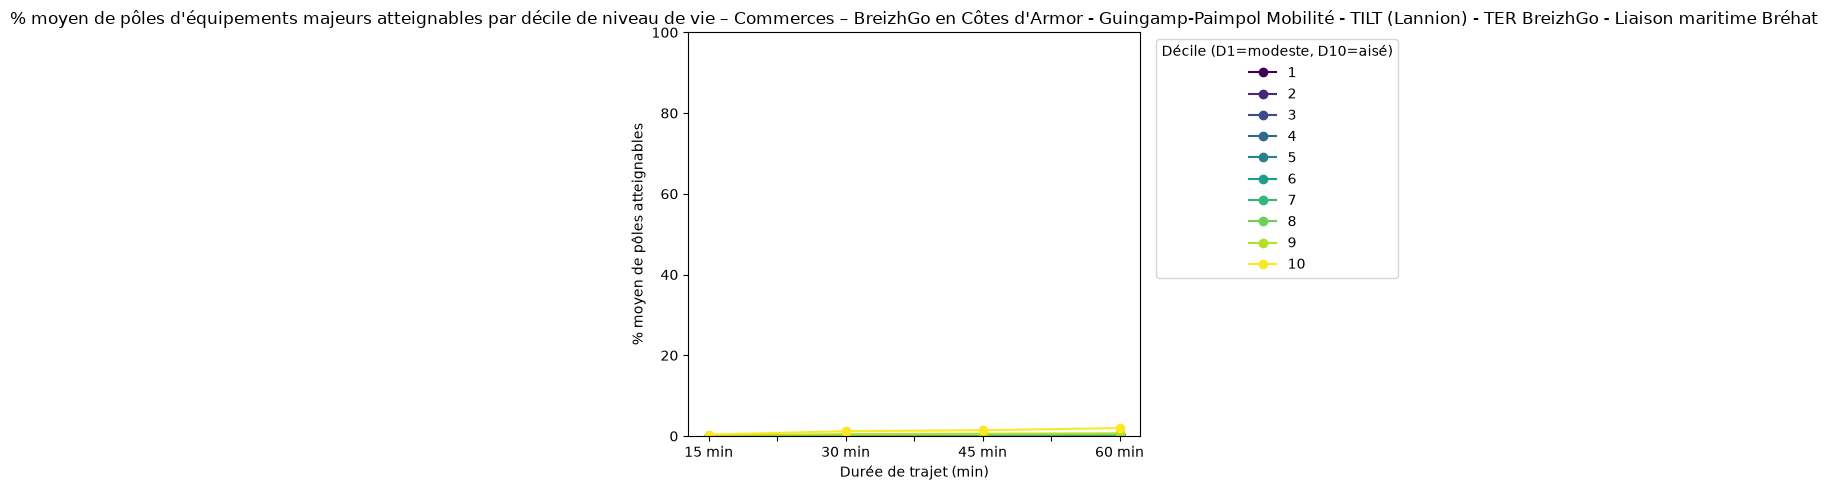

,15 min,30 min,45 min,60 min
Décile,,,,
1,0.0,0.1,0.1,0.1
2,0.0,0.1,0.1,0.1
3,0.0,0.1,0.1,0.1
4,0.0,0.1,0.1,0.2
5,0.0,0.1,0.2,0.2
6,0.0,0.2,0.2,0.2
7,0.0,0.2,0.2,0.3
8,0.1,0.3,0.4,0.5
9,0.1,0.4,0.6,0.6


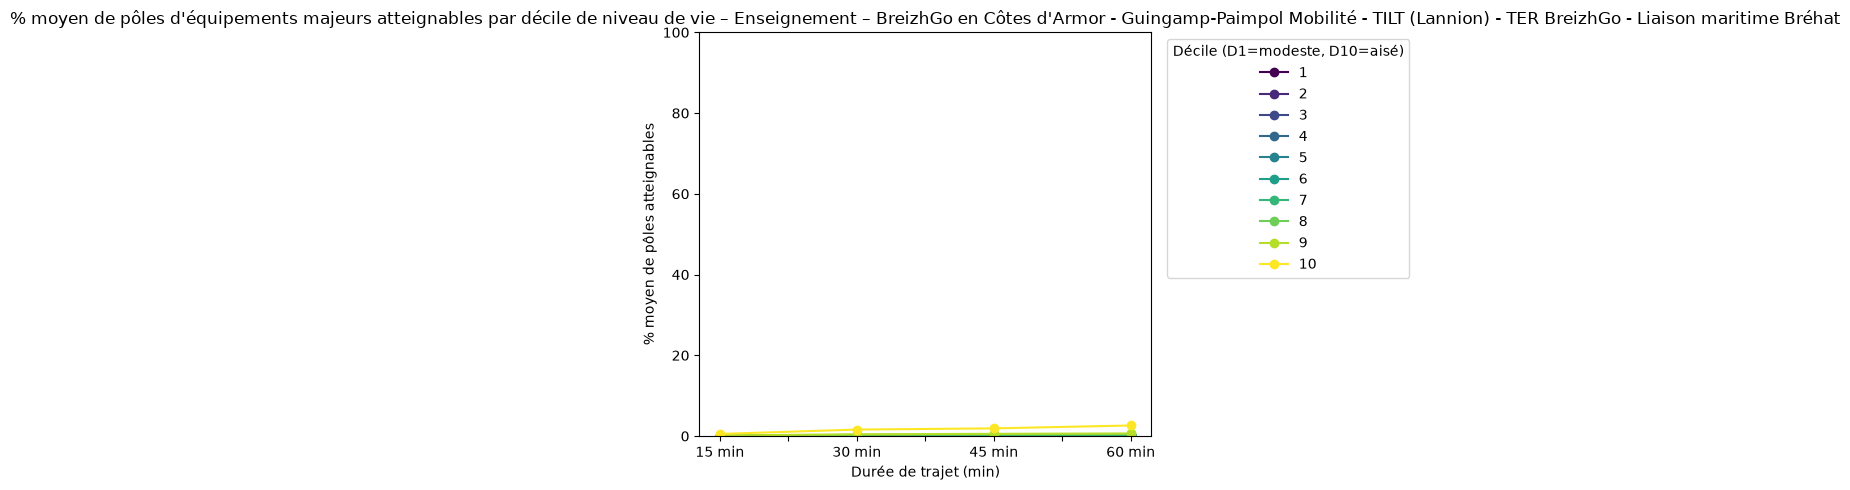

,15 min,30 min,45 min,60 min
Décile,,,,
1,0.0,0.1,0.1,0.1
2,0.0,0.1,0.1,0.1
3,0.0,0.1,0.1,0.1
4,0.0,0.1,0.1,0.1
5,0.0,0.1,0.2,0.2
6,0.0,0.1,0.2,0.2
7,0.0,0.2,0.2,0.3
8,0.1,0.3,0.4,0.5
9,0.1,0.5,0.6,0.7


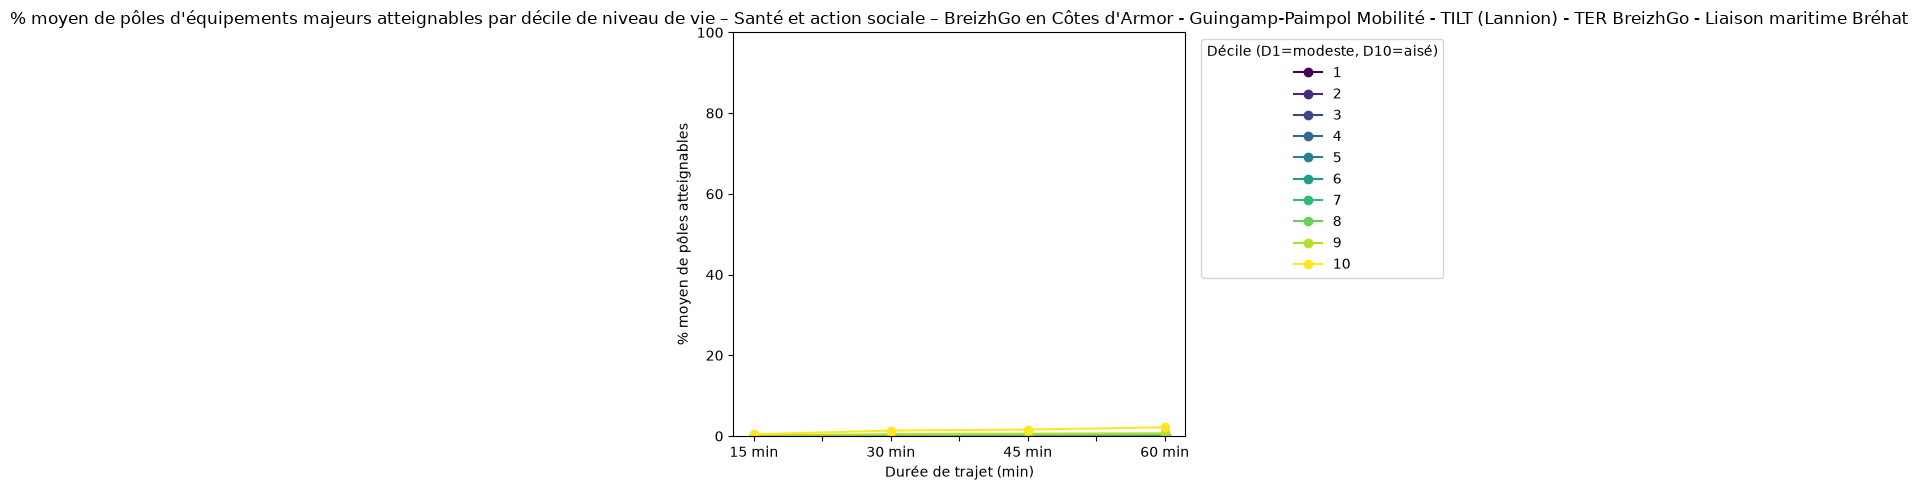

,15 min,30 min,45 min,60 min
Décile,,,,
1,0.0,0.1,0.1,0.1
2,0.0,0.1,0.1,0.1
3,0.0,0.1,0.1,0.2
4,0.0,0.1,0.1,0.2
5,0.0,0.1,0.2,0.2
6,0.0,0.1,0.2,0.2
7,0.0,0.2,0.2,0.3
8,0.1,0.3,0.3,0.4
9,0.1,0.4,0.5,0.6


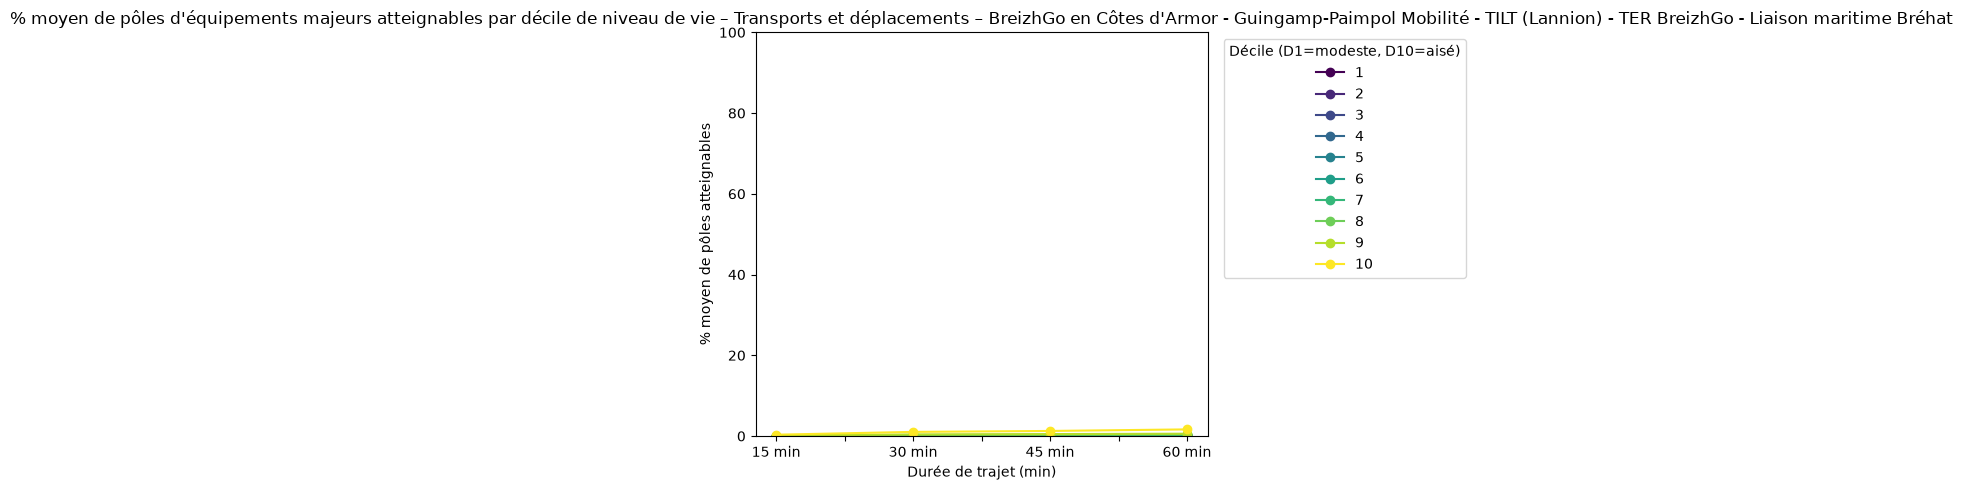

,15 min,30 min,45 min,60 min
Décile,,,,
1,0.0,0.1,0.1,0.1
2,0.0,0.1,0.1,0.1
3,0.0,0.1,0.1,0.1
4,0.0,0.1,0.1,0.2
5,0.0,0.1,0.2,0.2
6,0.0,0.1,0.2,0.2
7,0.0,0.2,0.2,0.3
8,0.1,0.3,0.4,0.4
9,0.1,0.4,0.5,0.6


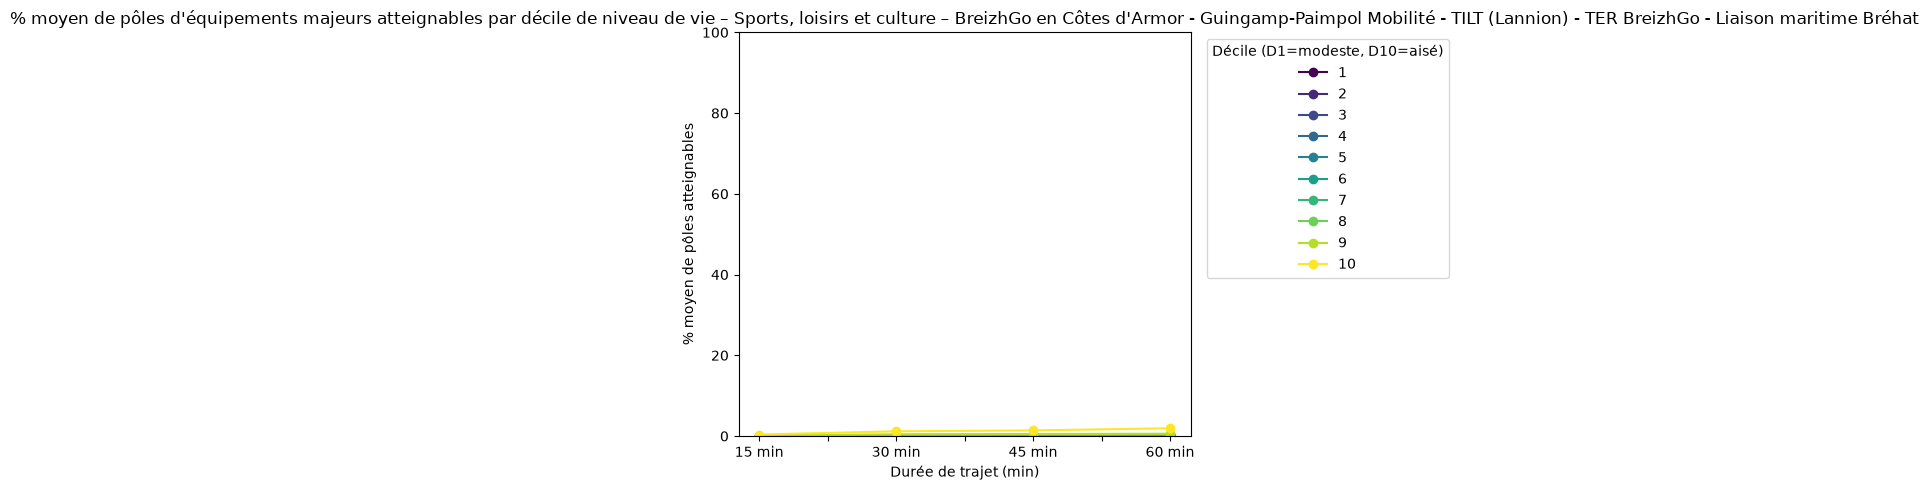

,15 min,30 min,45 min,60 min
Décile,,,,
1,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0


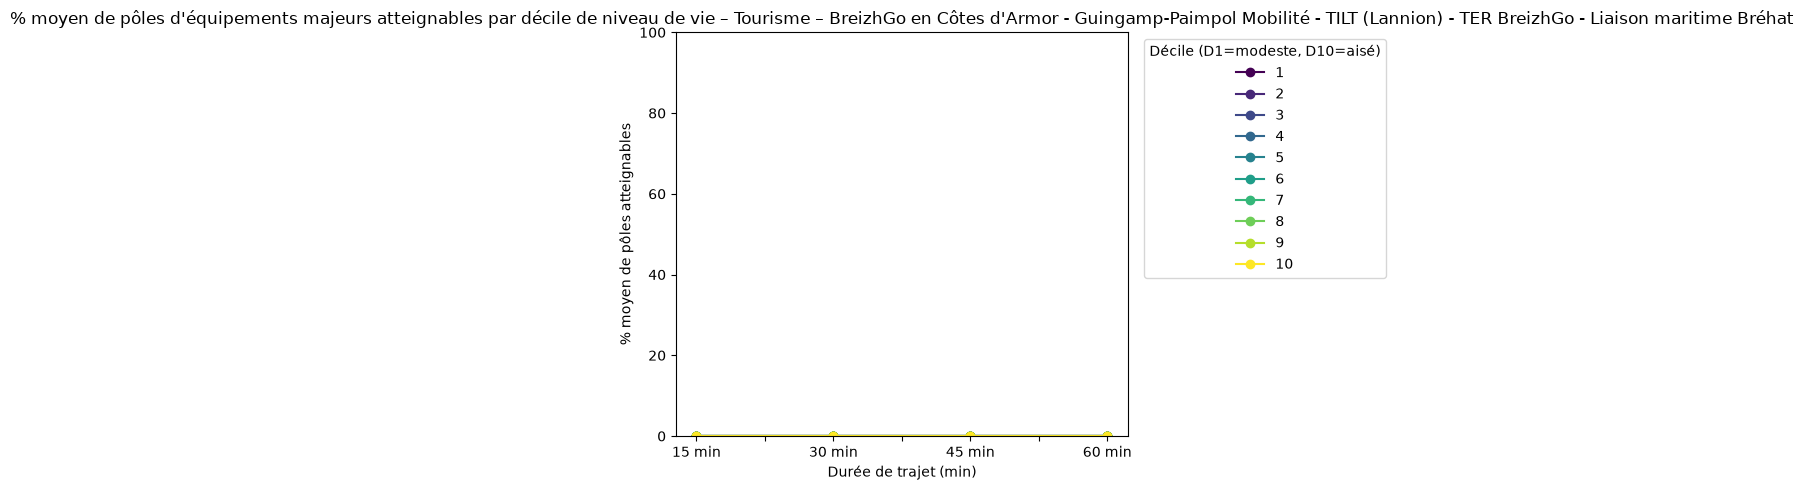

In [17]:
# Tableaux récapitulatifs : accès aux "pôles d'équipements" par domaine (30 vs 45 min)
#
# "Pôle d'équipements" pour un domaine d : carreau au-dessus du seuil défini
# dans SEUILS_DOMAINE (cellule "analyse BPE 1.1"), déjà calculé dans la colonne
# land_use_data["pole_equipements_{d}"].

from IPython.display import HTML, display
from src.utilitaires_matrix import pct_poles_atteignables_par_carreau, moyenne_ponderee_pct_poles

# --- Tableau 3 : % moyen (pondéré par la population) de pôles d'équipements
# majeurs atteignables, par domaine et par durée ------------------------------
#
# Contrairement aux tableaux 1/2 ci-dessus (accès binaire à au moins un pôle /
# à un seuil fixe de pôles), on calcule ici directement la moyenne — pondérée
# par la population de chaque carreau — du % de pôles-du-domaine atteignables
# depuis ce carreau : une mesure continue plutôt qu'un seuil.
#
# pct_poles_atteignables_par_carreau (src.utilitaires_matrix, partagée avec
# l'app Streamlit) calcule le % par carreau UNE SEULE FOIS par (domaine,
# durée) ; moyenne_ponderee_pct_poles réutilise ensuite ce résultat pour
# n'importe quel sous-ensemble de carreaux (toute la population en 3a, puis
# chaque décile en 3b) sans jamais re-scanner ttm. Avant cette factorisation,
# 3a+3b re-scannaient ttm depuis zéro à chaque décile — jusqu'à 320 scans
# complets (8 domaines x 10 déciles x 4 durées) au lieu de 32 sur un gros
# réseau, d'où cette cellule qui moulinait très longtemps.

CUTOFFS_PCT_MOYEN_POLES = [15, 30, 45, 60]

pct_par_carreau_domaine_cutoff = {
    (d, c): pct_poles_atteignables_par_carreau(land_use_data, ttm, d, c)
    for d in DOMAINES_BPE
    for c in CUTOFFS_PCT_MOYEN_POLES
}

# --- 3a. Vue d'ensemble : moyenne sur toute la population, par domaine x durée --

tableau_pct_moyen_poles = pd.DataFrame(
    [
        {
            "Domaine": nom_domaine,
            **{
                f"{c} min": moyenne_ponderee_pct_poles(pct_par_carreau_domaine_cutoff[(d, c)])
                for c in CUTOFFS_PCT_MOYEN_POLES
            },
        }
        for d, nom_domaine in DOMAINES_BPE.items()
    ]
).set_index("Domaine")

tableau_pct_moyen_poles_html = (
    tableau_pct_moyen_poles.style.format("{:.1f}")
    .set_caption(
        f"% moyen (pondéré par la population) de pôles d'équipements majeurs "
        f"atteignables, par domaine – {nom_reseau_str}"
    )
    .to_html()
)

display(HTML(tableau_pct_moyen_poles_html))

chemin_tableau_pct_moyen = os.path.join(output_path_reseau, f"tableau_pct_moyen_poles_{nom_reseau_str}.html")
with open(chemin_tableau_pct_moyen, "w", encoding="utf-8") as f:
    f.write(tableau_pct_moyen_poles_html)

# Même donnée que le tableau ci-dessus, en courbes (une par domaine, x = durée)
# plutôt qu'en table : plus lisible pour comparer l'allure de la progression
# entre domaines (ex: un domaine qui plafonne vite vs un qui continue de
# progresser à 60 min).
fig, ax = plt.subplots(figsize=(8, 5))
tableau_pct_moyen_poles.T.plot(marker="o", ax=ax)
ax.set_xlabel("Durée de trajet (min)")
ax.set_ylabel("% moyen de pôles atteignables")
ax.set_ylim(0, 100)
ax.set_title(f"% moyen de pôles d'équipements majeurs atteignables, par domaine – {nom_reseau_str}")
ax.legend(title="Domaine", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

chemin_courbe_pct_moyen = os.path.join(output_path_reseau, f"courbe_pct_moyen_poles_{nom_reseau_str}.png")
plt.savefig(chemin_courbe_pct_moyen, dpi=150, bbox_inches="tight")
plt.show()


# --- 3b. Déclinaison par décile de niveau de vie, un tableau par domaine ----
#
# Même décile que la section 9.3 (ind_snv, cellule "analyse accessibilite /
# pop" : carreaux sans donnée publiée exclus) : niveau_vie doit donc avoir
# été calculé au préalable (exécuter la cellule 9.3 avant celle-ci). Un
# tableau décile x durée par domaine, plutôt qu'un unique tableau plat
# domaine x décile x durée (moins lisible) — même logique que les figures
# 9.1/9.3 bouclées par domaine.

for d, nom_domaine in DOMAINES_BPE.items():
    lignes_decile = []
    for decile in sorted(niveau_vie["decile_niveau_vie"].unique()):
        carreaux_decile = niveau_vie.loc[niveau_vie["decile_niveau_vie"] == decile, "id"]
        lignes_decile.append(
            {
                "Décile": int(decile),
                **{
                    f"{c} min": moyenne_ponderee_pct_poles(
                        pct_par_carreau_domaine_cutoff[(d, c)], carreaux_ids=carreaux_decile
                    )
                    for c in CUTOFFS_PCT_MOYEN_POLES
                },
            }
        )

    tableau_decile_poles = pd.DataFrame(lignes_decile).set_index("Décile")
    tableau_decile_poles_html = (
        tableau_decile_poles.style.format("{:.1f}")
        .set_caption(
            f"% moyen de pôles d'équipements majeurs atteignables par décile de "
            f"niveau de vie (D1 = le plus modeste, D10 = le plus aisé) – "
            f"{nom_domaine} – {nom_reseau_str}"
        )
        .to_html()
    )
    display(HTML(tableau_decile_poles_html))

    chemin_tableau_decile_poles = os.path.join(
        output_path_reseau, f"tableau_pct_moyen_poles_decile_{d}_{nom_reseau_str}.html"
    )
    with open(chemin_tableau_decile_poles, "w", encoding="utf-8") as f:
        f.write(tableau_decile_poles_html)

    # Même donnée que le tableau ci-dessus, en courbes (une par décile, x =
    # durée) : cmap="viridis" reprend l'ordre des déciles (modeste -> aisé)
    # dans le dégradé de couleur, pour repérer visuellement l'écart entre
    # les extrêmes sans avoir à lire la légende.
    fig, ax = plt.subplots(figsize=(8, 5))
    tableau_decile_poles.T.plot(marker="o", ax=ax, cmap="viridis")
    ax.set_xlabel("Durée de trajet (min)")
    ax.set_ylabel("% moyen de pôles atteignables")
    ax.set_ylim(0, 100)
    ax.set_title(
        f"% moyen de pôles d'équipements majeurs atteignables par décile de niveau de "
        f"vie – {nom_domaine} – {nom_reseau_str}"
    )
    ax.legend(title="Décile (D1=modeste, D10=aisé)", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()

    chemin_courbe_decile_poles = os.path.join(
        output_path_reseau, f"courbe_pct_moyen_poles_decile_{d}_{nom_reseau_str}.png"
    )
    plt.savefig(chemin_courbe_decile_poles, dpi=150, bbox_inches="tight")
    plt.show()

In [18]:
#sauvegarde index

# Constitue/actualise un fichier CSV unique agrégeant, pour chaque réseau déjà
# traité (un run = un réseau), des indicateurs de synthèse par domaine BPE et
# par décile de niveau de vie — pensé pour des nuages de points comparatifs
# entre réseaux (benchmark), pas pour l'analyse détaillée d'un seul réseau
# (déjà couverte par les tableaux/courbes des cellules précédentes).
#
# Calcul délégué à src.utilitaires_matrix.calculer_index_benchmark, partagée
# avec l'app Streamlit (onglet Accessibilité) pour ne pas dupliquer la
# logique : % moyen des équipements pondérés du domaine (poids_gamme, PAS
# restreint aux "pôles" majeurs) accessibles en 30/45/60 min, et temps moyen
# pour en atteindre 25%/50%/75%, par domaine et par décile de niveau de vie
# (+ un groupe "Tous").
#
# niveau_vie doit avoir été calculé au préalable : exécuter la cellule
# "analyse accessibilite / pop" (9.3) avant celle-ci.
#
# Fichier UNIQUE partagé entre ce notebook (en local) et l'app Streamlit (sur
# le Space) via le dataset HF antoinechevre/accessibility-data
# (src.hf_cache.fusionner_et_envoyer_csv) : une relance pour un réseau déjà
# présent remplace ses lignes plutôt que de les dupliquer, la version la plus
# récente du fichier distant est toujours retéléchargée avant fusion (pour ne
# pas perdre des lignes ajoutées ailleurs, ex. depuis le Space).

from src.pipeline_donnees import RESEAUX_EXCLUS_BENCHMARK
from src.build_data_agglo import surface_km2_decoupage

CHEMIN_INDEX_BENCHMARK = os.path.join(BASE_DIR, "output", "index_benchmark_reseaux.csv")
NOM_FICHIER_INDEX_BENCHMARK_HF = "benchmark/index_benchmark_reseaux.csv"

# IDFM (~11 millions d'habitants) est sur une échelle de population sans
# commune mesure avec les autres réseaux du fichier (Lyon ~1M, Toulouse
# ~1M...) et écraserait les nuages de points comparatifs de l'onglet
# "Benchmark réseaux" — même exclusion que côté app (RESEAUX_EXCLUS_BENCHMARK,
# cf. src/pipeline_donnees.py), appliquée ici à l'écriture elle-même plutôt
# que de compter sur l'app pour le filtrer après coup.
if nom_reseau_str in RESEAUX_EXCLUS_BENCHMARK:
    print(
        f"{nom_reseau_str} exclu du fichier de benchmark inter-réseaux (échelle de "
        "population non comparable aux autres réseaux) — pas d'écriture dans l'index."
    )
else:
    # Si ce réseau, pour cette date_JOB, est déjà dans l'index (même après un
    # redémarrage du kernel), pas de recalcul : calculer_index_benchmark (8
    # domaines x cumulative_cutoff + tri de ttm) est coûteux et redonnerait le
    # même résultat. Repasser cette cellule après avoir modifié GTFS_PATH/la
    # date_JOB reste sûr : la nouvelle combinaison réseau/date_JOB n'est pas
    # encore dans le fichier donc le calcul a bien lieu.
    deja_enregistre = False
    if os.path.exists(CHEMIN_INDEX_BENCHMARK):
        tableau_existant = pd.read_csv(CHEMIN_INDEX_BENCHMARK, dtype={"date_JOB": str})
        deja_enregistre = (
            (tableau_existant["reseau"] == nom_reseau_str) & (tableau_existant["date_JOB"] == str(date_JOB))
        ).any()

    if deja_enregistre:
        print(
            f"Indicateurs déjà enregistrés pour {nom_reseau_str} (date JOB {date_JOB}) — "
            "pas de recalcul. Effacez la ligne correspondante dans le CSV pour forcer un réenregistrement."
        )
    else:
        tableau_benchmark = calculer_index_benchmark(BPE_agglo, land_use_data, ttm, DOMAINES_BPE, niveau_vie)

        # Métadonnées du run : réseau (agency_name du GTFS), ville principale (commune
        # desservie la plus peuplée, via geo.api.gouv.fr — cf. ville_principale),
        # date JOB de référence, véhicules.km ce jour-là (total_vkm_job, calculé en
        # cellule "Retourne différentes dates") et population totale de l'agglomération.
        codes_insee_reseau = pd.read_csv(DECOUPAGE_COM_PATH_CSV, dtype={"code_insee": str})["code_insee"]
        ville_principale_reseau = ville_principale(codes_insee_reseau)
        population_totale_reseau = land_use_data["population"].sum()
        surface_km2_reseau = surface_km2_decoupage(DECOUPAGE_COM_PATH_CSV)

        # Répartition par mode (bus / métro / tram) et nombre d'arrêts, pour le
        # graphique "véhicules.km & arrêts" de l'onglet Benchmark villes
        # françaises (src/nuage_points_reseau.py) — route_type direct (pas de
        # distinction RER/Transilien/TER par agence, contrairement à
        # views/troncons.py : indicateur simple, pas de raison de complexifier
        # ici pour IDFM, de toute façon exclu du benchmark ci-dessus).
        vkm_par_mode_job = vkm_par_ligne_job.merge(feed.routes[["route_id", "route_type"]], on="route_id", how="left")
        bus_km_job = vkm_par_mode_job.loc[vkm_par_mode_job["route_type"] == 3, "total_km"].sum()
        metro_km_job = vkm_par_mode_job.loc[vkm_par_mode_job["route_type"] == 1, "total_km"].sum()
        tram_km_job = vkm_par_mode_job.loc[vkm_par_mode_job["route_type"] == 0, "total_km"].sum()
        nombre_arrets_reseau = feed.stops["stop_id"].nunique()

        tableau_benchmark.insert(0, "nombre_arrets", nombre_arrets_reseau)
        tableau_benchmark.insert(0, "surface_km2", surface_km2_reseau)
        tableau_benchmark.insert(0, "tram_km_JOB", tram_km_job)
        tableau_benchmark.insert(0, "metro_km_JOB", metro_km_job)
        tableau_benchmark.insert(0, "bus_km_JOB", bus_km_job)
        tableau_benchmark.insert(0, "population_totale", population_totale_reseau)
        tableau_benchmark.insert(0, "vehicules_km_JOB", total_vkm_job)
        tableau_benchmark.insert(0, "date_fin", date_fin)
        tableau_benchmark.insert(0, "date_debut", date_debut)
        tableau_benchmark.insert(0, "date_JOB", date_JOB)
        tableau_benchmark.insert(0, "ville_principale", ville_principale_reseau)
        tableau_benchmark.insert(0, "date_run", datetime.datetime.now().strftime("%Y-%m-%d %H:%M"))
        tableau_benchmark.insert(0, "reseau", nom_reseau_str)

        tableau_benchmark_complet, succes_envoi_benchmark = fusionner_et_envoyer_csv(
            tableau_benchmark,
            NOM_FICHIER_INDEX_BENCHMARK_HF,
            CHEMIN_INDEX_BENCHMARK,
            colonne_cle="reseau",
            valeur_cle=nom_reseau_str,
        )

        print(
            f"\u2713 {len(tableau_benchmark)} ligne(s) pour {nom_reseau_str} "
            f"(ville principale : {ville_principale_reseau}) enregistrée(s) dans {CHEMIN_INDEX_BENCHMARK} "
            f"et {NOM_FICHIER_INDEX_BENCHMARK_HF}"
        )
        print(f"  ({tableau_benchmark_complet['reseau'].nunique()} réseau(x) au total dans l'index)")
        if not succes_envoi_benchmark:
            print(
                "\u26a0 Enregistré en local uniquement — l'envoi vers Hugging Face a échoué, ce "
                "réseau restera invisible des autres déploiements/onglets Benchmark tant qu'il "
                "n'aura pas été renvoyé."
            )

        display(HTML(tableau_benchmark.to_html(index=False)))


✓ 77 ligne(s) pour BreizhGo en Côtes d'Armor - Guingamp-Paimpol Mobilité - TILT (Lannion) - TER BreizhGo - Liaison maritime Bréhat (ville principale : Saint-Brieuc) enregistrée(s) dans /Users/antoinechevre/Documents/_0_Programme/1_Analyse_Accessibilité/Accessibility_analysis/output/index_benchmark_reseaux.csv et benchmark/index_benchmark_reseaux.csv
  (69 réseau(x) au total dans l'index)


reseau,date_run,ville_principale,date_JOB,date_debut,date_fin,vehicules_km_JOB,population_totale,bus_km_JOB,metro_km_JOB,tram_km_JOB,surface_km2,nombre_arrets,domaine,nom_domaine,decile,pct_equipement_pondere_30min,pct_equipement_pondere_45min,pct_equipement_pondere_60min,temps_atteinte_25pct_min,temps_atteinte_50pct_min,temps_atteinte_75pct_min
BreizhGo en Côtes d'Armor - Guingamp-Paimpol Mobilité - TILT (Lannion) - TER BreizhGo - Liaison maritime Bréhat,2026-08-29 13:31,Saint-Brieuc,20260827,20260819,20261117,12828.314918,336621.0,8835.203257,0.0,0.0,2176.592591,1561,O,Tout équipements pondérés,Tous,1.417079,1.733100,2.258023,118.708666,120.0,120.0
BreizhGo en Côtes d'Armor - Guingamp-Paimpol Mobilité - TILT (Lannion) - TER BreizhGo - Liaison maritime Bréhat,2026-08-29 13:31,Saint-Brieuc,20260827,20260819,20261117,12828.314918,336621.0,8835.203257,0.0,0.0,2176.592591,1561,O,Tout équipements pondérés,D1,0.047092,0.072193,0.097696,120.000000,120.0,120.0
BreizhGo en Côtes d'Armor - Guingamp-Paimpol Mobilité - TILT (Lannion) - TER BreizhGo - Liaison maritime Bréhat,2026-08-29 13:31,Saint-Brieuc,20260827,20260819,20261117,12828.314918,336621.0,8835.203257,0.0,0.0,2176.592591,1561,O,Tout équipements pondérés,D2,0.062648,0.083372,0.105815,120.000000,120.0,120.0
BreizhGo en Côtes d'Armor - Guingamp-Paimpol Mobilité - TILT (Lannion) - TER BreizhGo - Liaison maritime Bréhat,2026-08-29 13:31,Saint-Brieuc,20260827,20260819,20261117,12828.314918,336621.0,8835.203257,0.0,0.0,2176.592591,1561,O,Tout équipements pondérés,D3,0.067575,0.106960,0.129844,120.000000,120.0,120.0
BreizhGo en Côtes d'Armor - Guingamp-Paimpol Mobilité - TILT (Lannion) - TER BreizhGo - Liaison maritime Bréhat,2026-08-29 13:31,Saint-Brieuc,20260827,20260819,20261117,12828.314918,336621.0,8835.203257,0.0,0.0,2176.592591,1561,O,Tout équipements pondérés,D4,0.072160,0.099921,0.120284,120.000000,120.0,120.0
BreizhGo en Côtes d'Armor - Guingamp-Paimpol Mobilité - TILT (Lannion) - TER BreizhGo - Liaison maritime Bréhat,2026-08-29 13:31,Saint-Brieuc,20260827,20260819,20261117,12828.314918,336621.0,8835.203257,0.0,0.0,2176.592591,1561,O,Tout équipements pondérés,D5,0.097929,0.166118,0.206844,120.000000,120.0,120.0
BreizhGo en Côtes d'Armor - Guingamp-Paimpol Mobilité - TILT (Lannion) - TER BreizhGo - Liaison maritime Bréhat,2026-08-29 13:31,Saint-Brieuc,20260827,20260819,20261117,12828.314918,336621.0,8835.203257,0.0,0.0,2176.592591,1561,O,Tout équipements pondérés,D6,0.099213,0.146403,0.183961,120.000000,120.0,120.0
BreizhGo en Côtes d'Armor - Guingamp-Paimpol Mobilité - TILT (Lannion) - TER BreizhGo - Liaison maritime Bréhat,2026-08-29 13:31,Saint-Brieuc,20260827,20260819,20261117,12828.314918,336621.0,8835.203257,0.0,0.0,2176.592591,1561,O,Tout équipements pondérés,D7,0.156825,0.235458,0.295981,120.000000,120.0,120.0
BreizhGo en Côtes d'Armor - Guingamp-Paimpol Mobilité - TILT (Lannion) - TER BreizhGo - Liaison maritime Bréhat,2026-08-29 13:31,Saint-Brieuc,20260827,20260819,20261117,12828.314918,336621.0,8835.203257,0.0,0.0,2176.592591,1561,O,Tout équipements pondérés,D8,0.271605,0.398804,0.500222,120.000000,120.0,120.0
BreizhGo en Côtes d'Armor - Guingamp-Paimpol Mobilité - TILT (Lannion) - TER BreizhGo - Liaison maritime Bréhat,2026-08-29 13:31,Saint-Brieuc,20260827,20260819,20261117,12828.314918,336621.0,8835.203257,0.0,0.0,2176.592591,1561,O,Tout équipements pondérés,D9,0.431257,0.599948,0.687076,120.000000,120.0,120.0
